In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_link= 'https://drive.google.com/file/d/1rIFF4ld3CfmOnx2_kT06UwawLOolT5u7/view'
# get the id part of the file
id = file_link.split("/")[-2]
# creating a new link using the id for better readability of csv file in pandas
new_link = f'https://drive.google.com/uc?id={id}'
dataset = pd.read_csv(new_link)
print(dataset.keys())

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'will_change_career'],
      dtype='object')


In [ ]:
file_link= 'https://drive.google.com/file/d/1rIFF4ld3CfmOnx2_kT06UwawLOolT5u7/view'
# get the id part of the file
id = file_link.split("/")[-2]
# creating a new link using the id for better readability of csv file in pandas
new_link = f'https://drive.google.com/uc?id={id}'
processed_ds = pd.read_csv(new_link)
print(processed_ds.keys())

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'will_change_career'],
      dtype='object')


# Before Preprocessing

In [ ]:
dataset[:20]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0


In [ ]:
dataset.shape

(5000, 14)

In [ ]:
dataset.drop('enrollee_id', axis=1, inplace=True)

In [ ]:
dataset.drop_duplicates()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,city_21,0.624,Female,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,NaN,1,114,1
4996,city_21,0.624,Male,No relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,64,1
4997,city_16,0.910,Male,No relevent experience,no_enrollment,High School,NaN,>20,5000-9999,Pvt Ltd,>4,89,0
4998,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,10,10000+,Pvt Ltd,>4,20,1


In [ ]:
print(dataset.isnull().sum())

city                         0
city_development_index       0
gender                    1113
relevent_experience          0
enrolled_university        107
education_level            118
major_discipline           724
experience                  11
company_size              1571
company_type              1621
last_new_job               104
training_hours               0
will_change_career           0
dtype: int64


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    5000 non-null   object 
 1   city_development_index  5000 non-null   float64
 2   gender                  3887 non-null   object 
 3   relevent_experience     5000 non-null   object 
 4   enrolled_university     4893 non-null   object 
 5   education_level         4882 non-null   object 
 6   major_discipline        4276 non-null   object 
 7   experience              4989 non-null   object 
 8   company_size            3429 non-null   object 
 9   company_type            3379 non-null   object 
 10  last_new_job            4896 non-null   object 
 11  training_hours          5000 non-null   int64  
 12  will_change_career      5000 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 507.9+ KB


In [ ]:
dataset.describe(include='all')

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
count,5000,5000.000000,3887,5000,4893,4882,4276,4989,3429,3379,4896,5000.000000,5000.000000
unique,113,NaN,3,2,3,5,6,22,8,6,6,NaN,NaN
top,city_103,NaN,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1,NaN,NaN
freq,1163,NaN,3507,3598,3571,3037,3786,859,813,2550,2094,NaN,NaN
mean,NaN,0.829410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.027200,0.252400
std,NaN,0.122429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.946693,0.434433
min,NaN,0.448000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
25%,NaN,0.743000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,0.000000
50%,NaN,0.903000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.000000,0.000000
75%,NaN,0.920000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.000000,1.000000


In [ ]:
dataset.nunique()

,0
city,113
city_development_index,85
gender,3
relevent_experience,2
enrolled_university,3
education_level,5
major_discipline,6
experience,22
company_size,8
company_type,6


In [ ]:
cat_data=dataset.select_dtypes(include=['object'])
num_data=dataset.select_dtypes(include=np.number)

In [ ]:

cat_cols=dataset.select_dtypes(include=['object']).columns.tolist()
num_cols = dataset.select_dtypes(include=np.number).columns.tolist()
print(f'There are {len(cat_cols)} categorical features:', '\n')
print("Categorical Variables:")
print(cat_cols)
print(f'There are {len(num_cols)} numerical features:', '\n')
print("Numerical Variables:")
print(num_cols)

There are 10 categorical features: 

Categorical Variables:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']
There are 3 numerical features: 

Numerical Variables:
['city_development_index', 'training_hours', 'will_change_career']


In [ ]:
numerical_data = dataset.select_dtypes(include='number')
numerical_data

,city_development_index,training_hours,will_change_career
0,0.920,36,1
1,0.776,47,0
2,0.624,83,0
3,0.789,52,1
4,0.767,8,0
...,...,...,...
4995,0.624,114,1
4996,0.624,64,1
4997,0.910,89,0
4998,0.920,20,1


In [ ]:
categorical_data = dataset.select_dtypes(include='object')
categorical_data

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
0,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1
1,city_40,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4
2,city_21,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0
3,city_115,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0
4,city_162,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4
...,...,...,...,...,...,...,...,...,...,...
4995,city_21,Female,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,NaN,1
4996,city_21,Male,No relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1
4997,city_16,Male,No relevent experience,no_enrollment,High School,NaN,>20,5000-9999,Pvt Ltd,>4
4998,city_103,Female,Has relevent experience,no_enrollment,Graduate,STEM,10,10000+,Pvt Ltd,>4


In [ ]:
num_data.var()

,0
city_development_index,0.014989
training_hours,3593.605981
will_change_career,0.188732


In [ ]:
num_data.skew()

,0
city_development_index,-1.013328
training_hours,1.853677
will_change_career,1.140333


<function matplotlib.pyplot.show(close=None, block=None)>

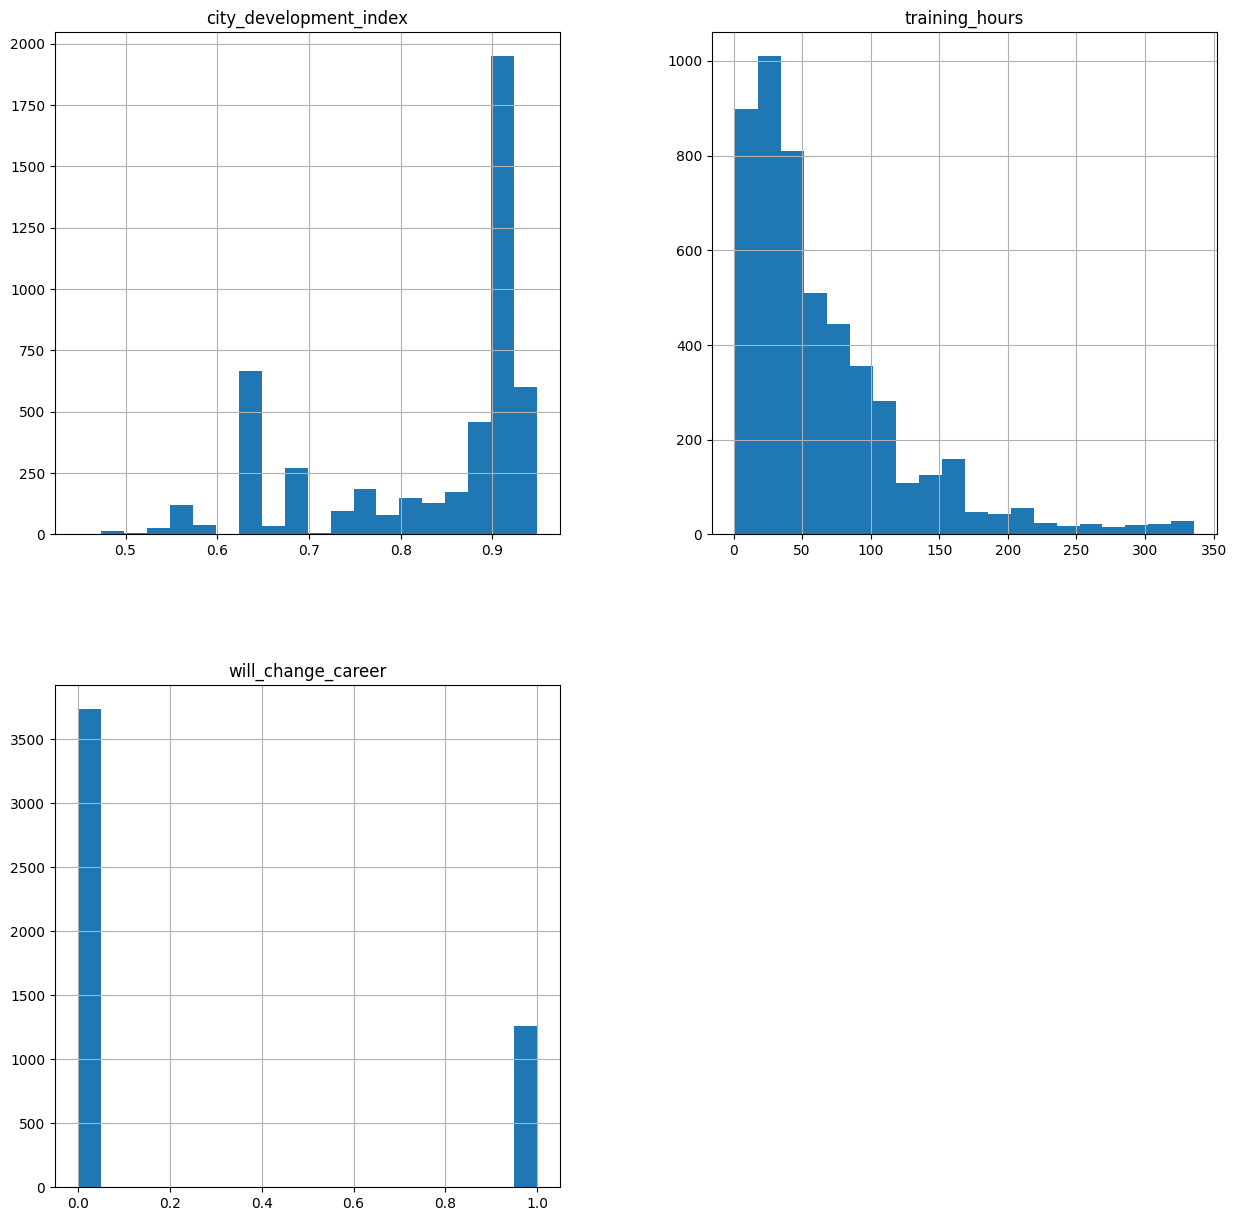

In [ ]:
dataset.hist(figsize=(15,15),bins=20)
plt.show

Correlation Matrix:
                        city_development_index  training_hours  \
city_development_index                1.000000        0.004717   
training_hours                        0.004717        1.000000   
will_change_career                   -0.346808       -0.022170   

                        will_change_career  
city_development_index           -0.346808  
training_hours                   -0.022170  
will_change_career                1.000000  


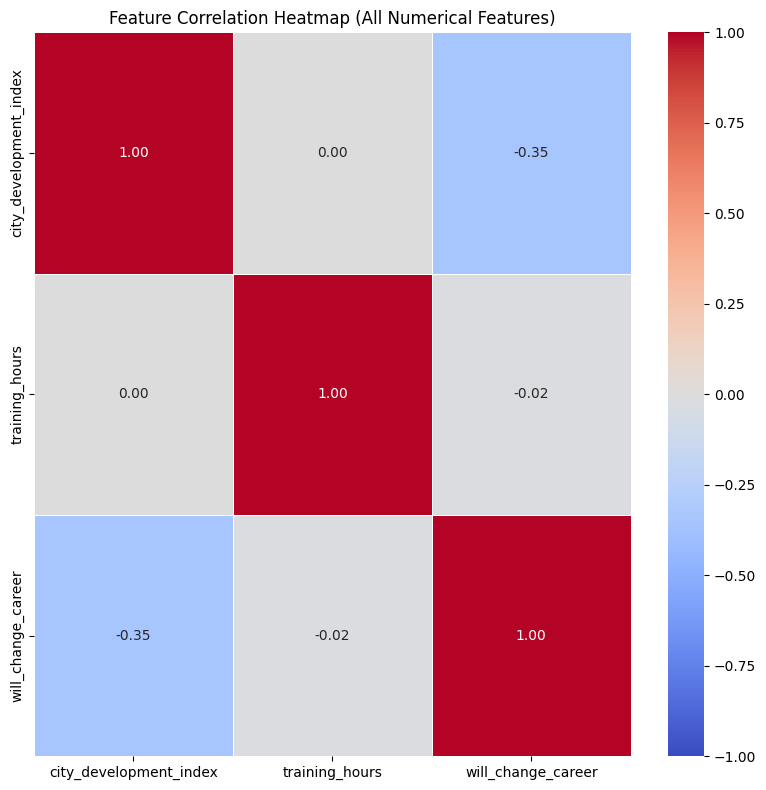

In [ ]:
correlation_matrix = dataset.corr(numeric_only=True)

# Display correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            fmt='.2f',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap (All Numerical Features)')
plt.tight_layout()
plt.show()

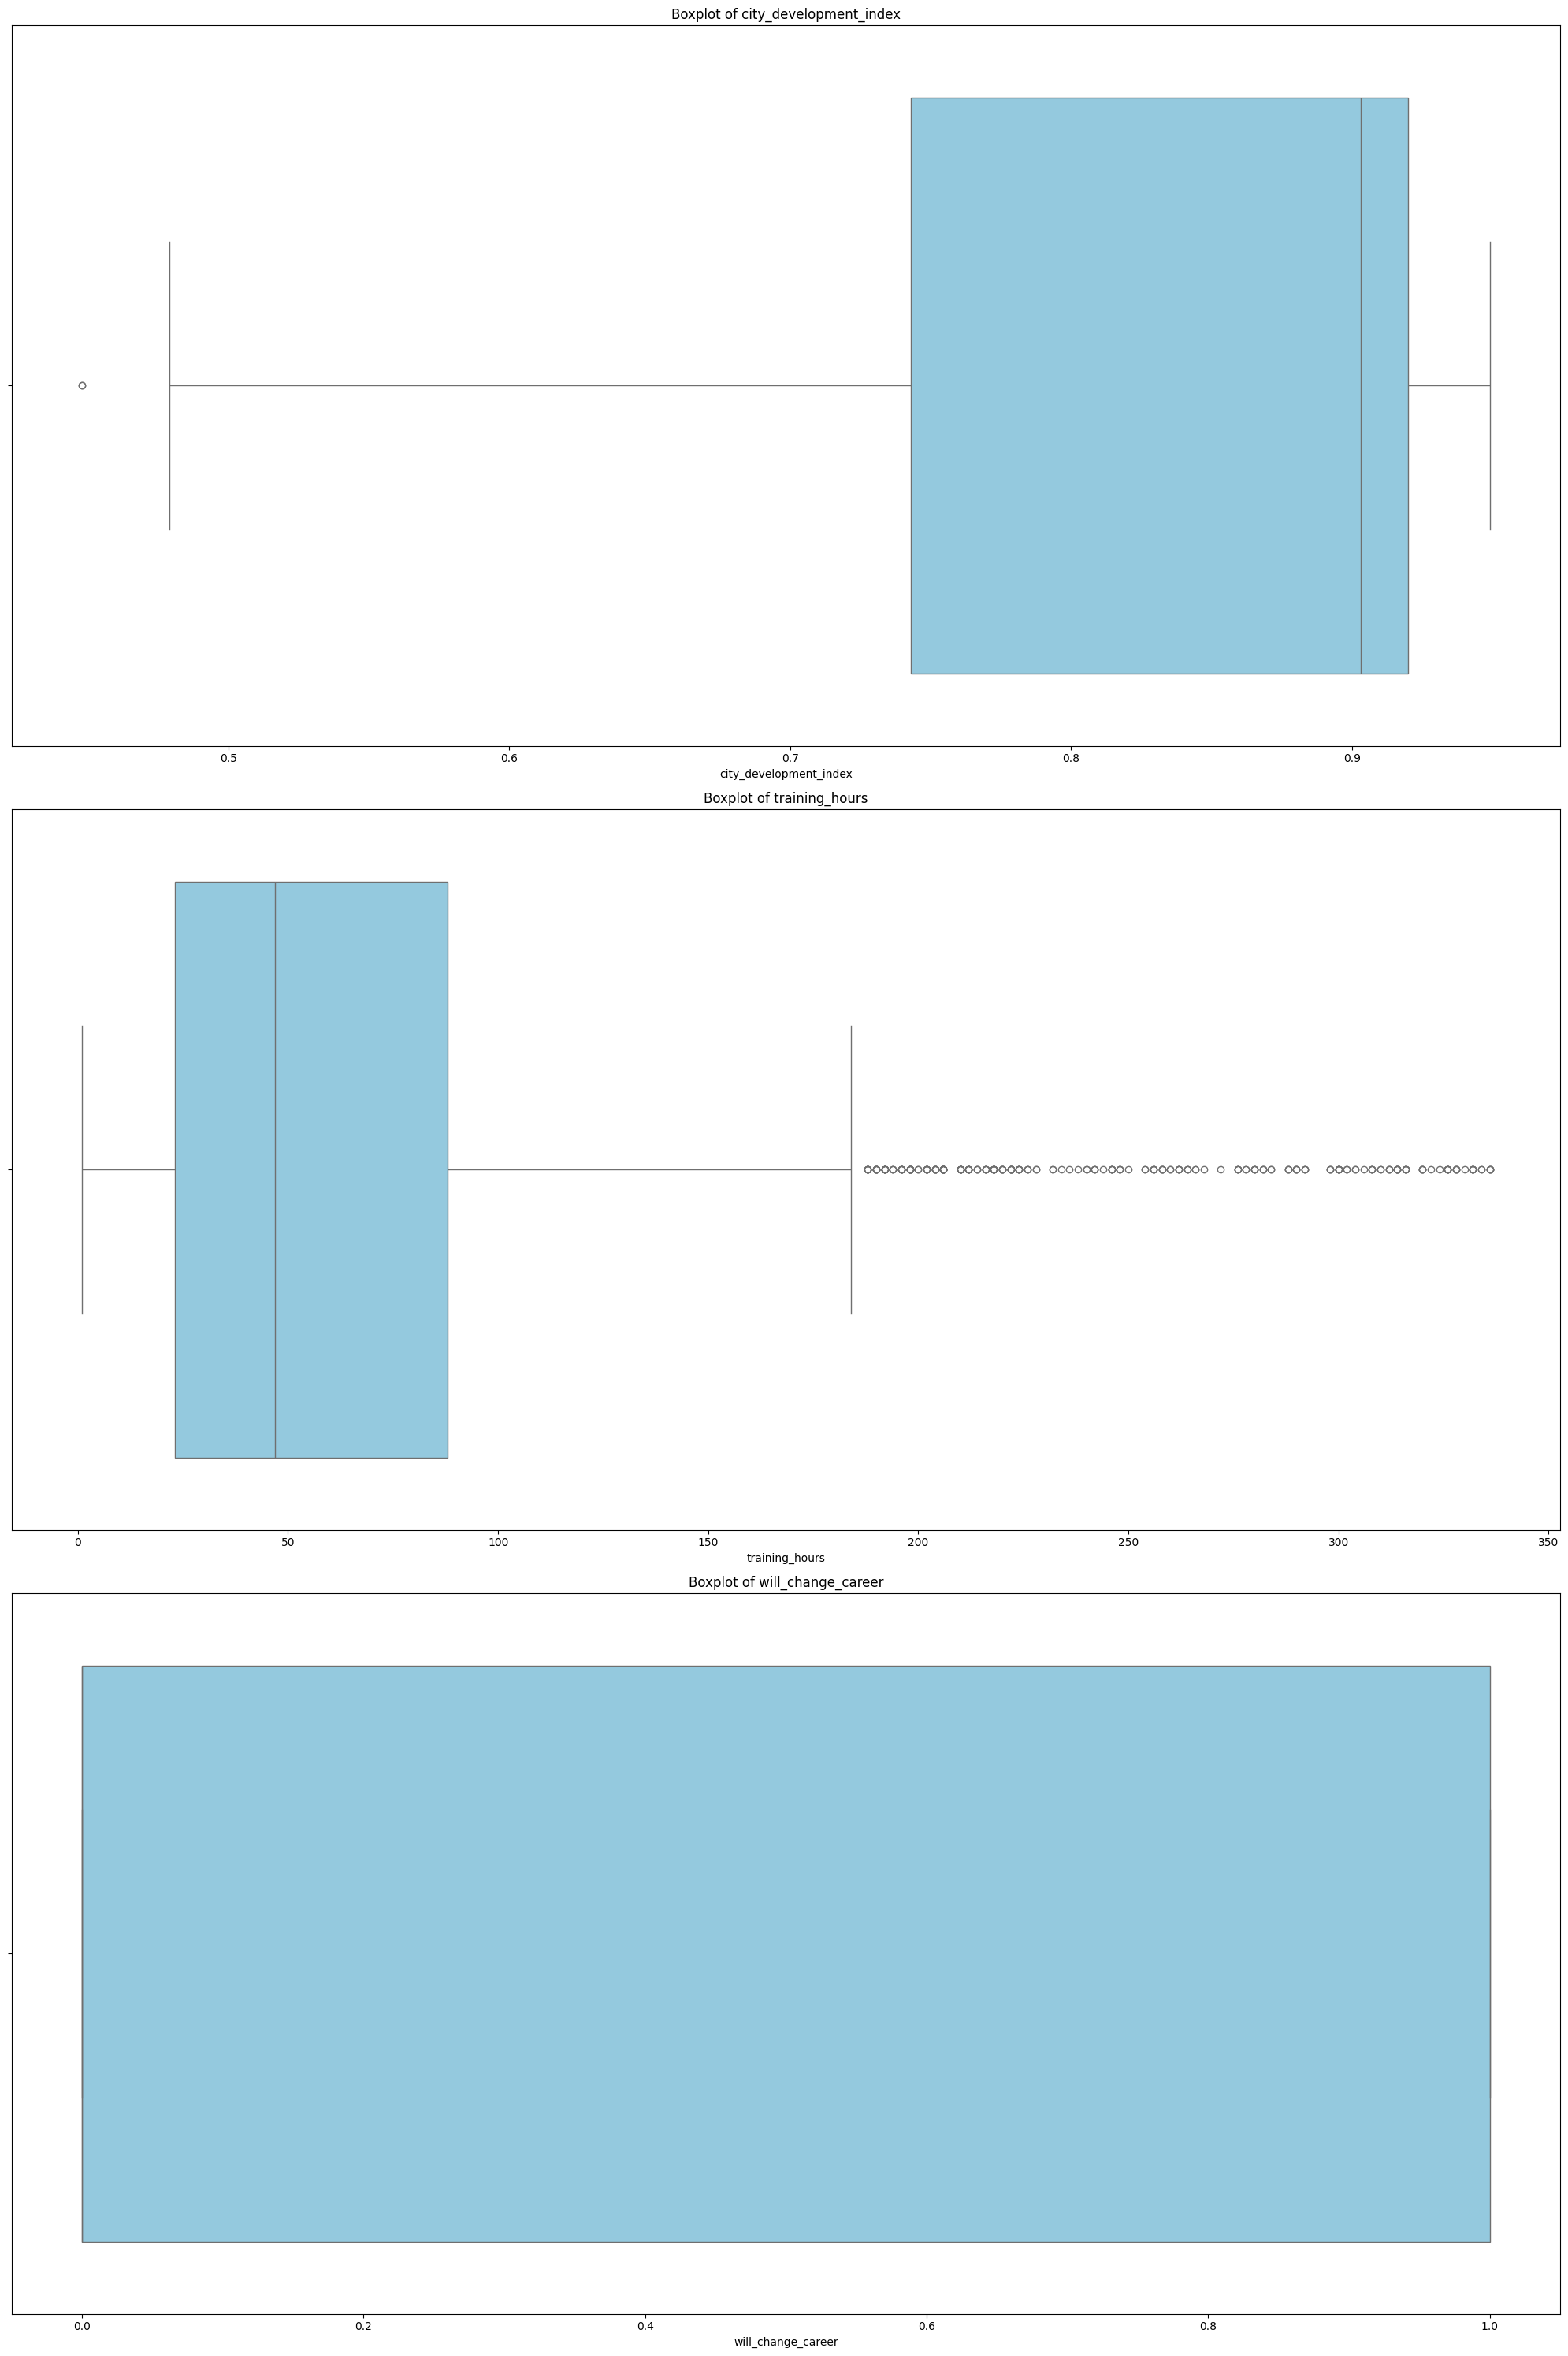

In [ ]:
# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

will_change_career
0    3738
1    1262
Name: count, dtype: int64


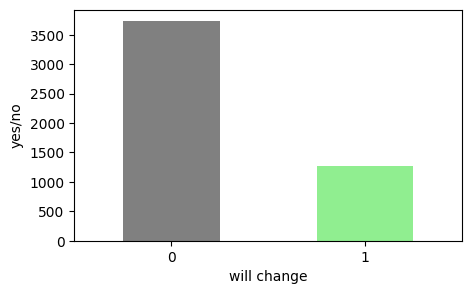

In [ ]:
print(dataset.value_counts('will_change_career'))
plt.figure(figsize=(5,3))
dataset['will_change_career'].value_counts().plot(kind='bar', color=['grey', 'lightgreen'])
plt.title('')
plt.xlabel('will change')
plt.ylabel('yes/no')
plt.xticks(rotation = 0)
plt.show()

<Figure size 800x600 with 0 Axes>

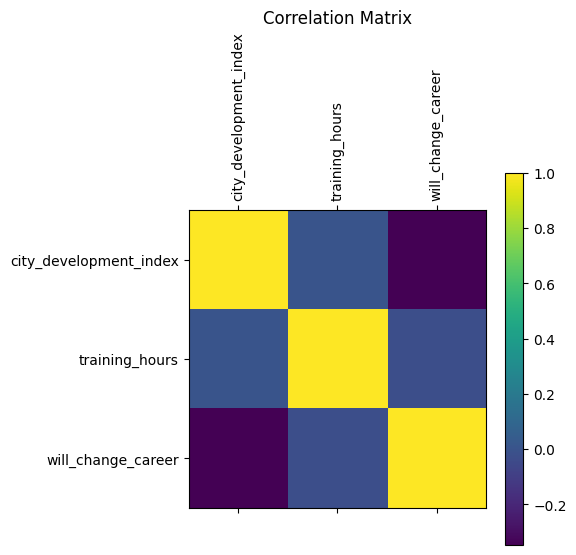

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = dataset.corr(numeric_only=True)
plt.matshow(correlation_matrix)
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()

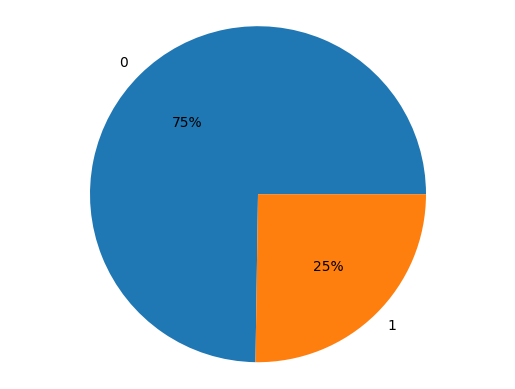

In [ ]:
# Pie chart
w,x=dataset['will_change_career'].value_counts()

classes=[w,x]
class_labels=["0","1"]
plt.pie(classes,labels=class_labels,autopct='%0.0f%%')
plt.axis("equal")
plt.show()

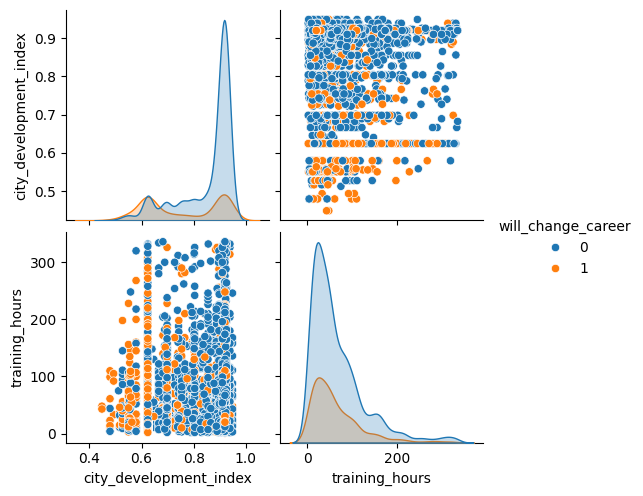

In [ ]:
# scatter plot
sns.pairplot(dataset, hue='will_change_career')

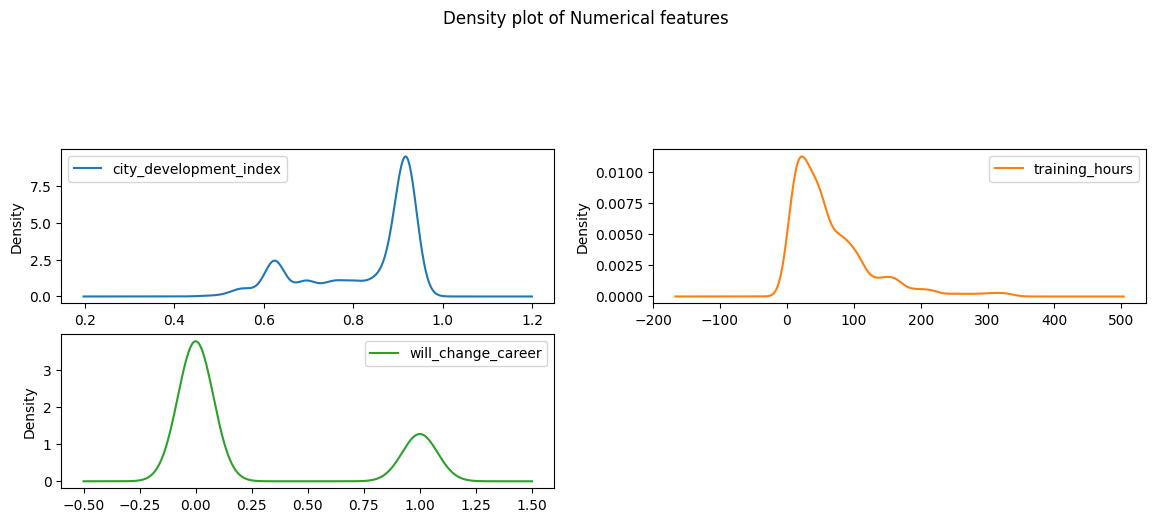

In [ ]:
dataset.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

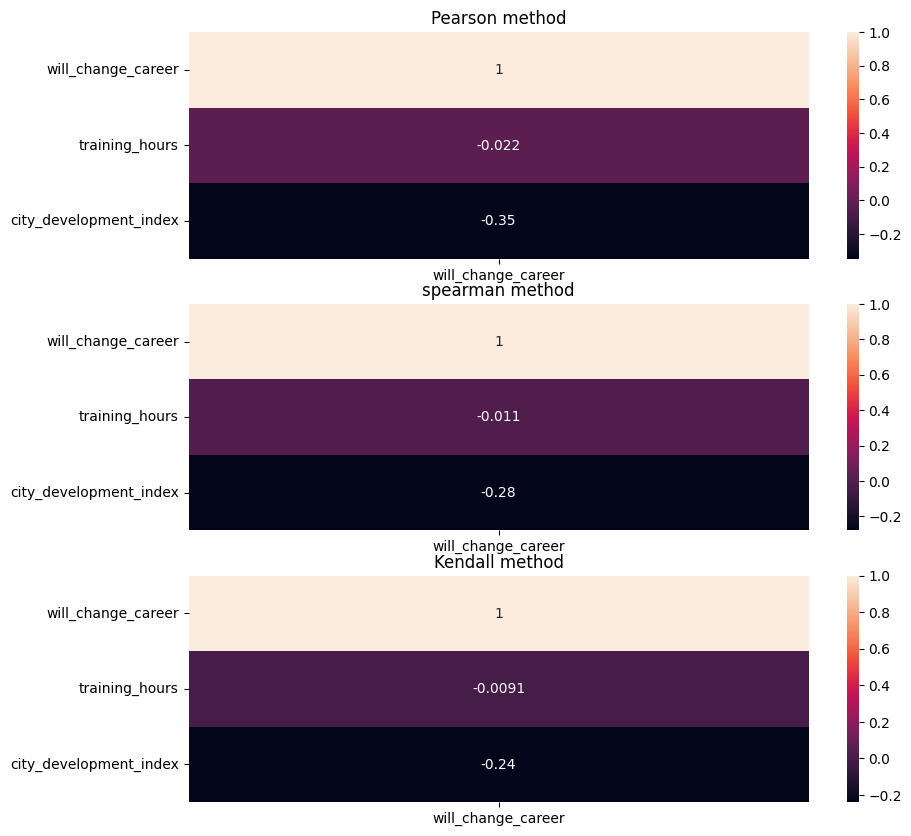

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
## Correlation coefficient using different methods
corr1 = num_data.corr('pearson')[['will_change_career']].sort_values(by='will_change_career', ascending=False)
corr2 = num_data.corr('spearman')[['will_change_career']].sort_values(by='will_change_career', ascending=False)
corr3 = num_data.corr('kendall')[['will_change_career']].sort_values(by='will_change_career', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

# After Preprocessing

In [ ]:
print(processed_ds.isnull().sum())

enrollee_id                  0
city                         0
city_development_index       0
gender                    1113
relevent_experience          0
enrolled_university        107
education_level            118
major_discipline           724
experience                  11
company_size              1571
company_type              1621
last_new_job               104
training_hours               0
will_change_career           0
dtype: int64


In [ ]:
cat_cols = processed_ds.select_dtypes(include=['object']).columns.tolist()
num_cols = processed_ds.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']
Numerical Variables:
['enrollee_id', 'city_development_index', 'training_hours', 'will_change_career']


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    processed_ds[f"{col}_encoded"] = le.fit_transform(processed_ds[col])

print(processed_ds[[f"{col}_encoded" for col in cat_cols]].head())

   city_encoded  gender_encoded  relevent_experience_encoded  \
0             5               1                            0   
1            68               1                            1   
2            56               3                            1   
3            13               3                            1   
4            46               1                            0   

   enrolled_university_encoded  education_level_encoded  \
0                            2                        0   
1                            2                        0   
2                            0                        0   
3                            3                        0   
4                            2                        2   

   major_discipline_encoded  experience_encoded  company_size_encoded  \
0                         5                  21                     8   
1                         5                   6                     3   
2                         5              

In [ ]:
cat_cols = processed_ds.select_dtypes(include=['object']).columns.tolist()
num_cols = processed_ds.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']
Numerical Variables:
['enrollee_id', 'city_development_index', 'training_hours', 'will_change_career', 'city_encoded', 'gender_encoded', 'relevent_experience_encoded', 'enrolled_university_encoded', 'education_level_encoded', 'major_discipline_encoded', 'experience_encoded', 'company_size_encoded', 'company_type_encoded', 'last_new_job_encoded']


In [ ]:
encodednull_cols = ['gender_encoded','enrolled_university_encoded','education_level_encoded','major_discipline_encoded','experience_encoded','company_size_encoded','company_type_encoded','last_new_job_encoded']

for col in encodednull_cols:
    max_val = processed_ds[col].max()
    processed_ds[col] = processed_ds[col].replace(max_val, np.nan) #after the null val's have been encoded, turning those back to NULL

In [ ]:
print(processed_ds.isnull().sum())

enrollee_id                       0
city                              0
city_development_index            0
gender                         1113
relevent_experience               0
enrolled_university             107
education_level                 118
major_discipline                724
experience                       11
company_size                   1571
company_type                   1621
last_new_job                    104
training_hours                    0
will_change_career                0
city_encoded                      0
gender_encoded                 1113
relevent_experience_encoded       0
enrolled_university_encoded     107
education_level_encoded         118
major_discipline_encoded        724
experience_encoded               11
company_size_encoded           1571
company_type_encoded           1621
last_new_job_encoded            104
dtype: int64


In [ ]:
processed_ds.nunique()

,0
enrollee_id,5000
city,113
city_development_index,85
gender,3
relevent_experience,2
enrolled_university,3
education_level,5
major_discipline,6
experience,22
company_size,8


In [ ]:
processed_ds.drop(columns=cat_cols, inplace=True)

In [ ]:
processed_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   enrollee_id                  5000 non-null   int64  
 1   city_development_index       5000 non-null   float64
 2   training_hours               5000 non-null   int64  
 3   will_change_career           5000 non-null   int64  
 4   city_encoded                 5000 non-null   int64  
 5   gender_encoded               3887 non-null   float64
 6   relevent_experience_encoded  5000 non-null   int64  
 7   enrolled_university_encoded  4893 non-null   float64
 8   education_level_encoded      4882 non-null   float64
 9   major_discipline_encoded     4276 non-null   float64
 10  experience_encoded           4989 non-null   float64
 11  company_size_encoded         3429 non-null   float64
 12  company_type_encoded         3379 non-null   float64
 13  last_new_job_encod

In [ ]:
from sklearn.impute import KNNImputer

# Use KNNImputer to impute missing values according to similarity to other rows
imputer = KNNImputer(n_neighbors=1)  # Use n_neighbors=1 for the closest row
processed_ds = pd.DataFrame(imputer.fit_transform(processed_ds), columns=processed_ds.columns)

print(processed_ds.isnull().sum())

enrollee_id                    0
city_development_index         0
training_hours                 0
will_change_career             0
city_encoded                   0
gender_encoded                 0
relevent_experience_encoded    0
enrolled_university_encoded    0
education_level_encoded        0
major_discipline_encoded       0
experience_encoded             0
company_size_encoded           0
company_type_encoded           0
last_new_job_encoded           0
dtype: int64


In [ ]:
processed_ds.drop('enrollee_id', axis=1, inplace=True)
processed_ds.nunique()

,0
city_development_index,85
training_hours,238
will_change_career,2
city_encoded,113
gender_encoded,3
relevent_experience_encoded,2
enrolled_university_encoded,3
education_level_encoded,5
major_discipline_encoded,6
experience_encoded,22


In [ ]:
processed_ds[:50]

,city_development_index,training_hours,will_change_career,city_encoded,gender_encoded,relevent_experience_encoded,enrolled_university_encoded,education_level_encoded,major_discipline_encoded,experience_encoded,company_size_encoded,company_type_encoded,last_new_job_encoded
0,0.920,36.0,1.0,5.0,1.0,0.0,2.0,0.0,5.0,21.0,2.0,5.0,1.0
1,0.776,47.0,0.0,68.0,1.0,1.0,2.0,0.0,5.0,6.0,3.0,5.0,5.0
2,0.624,83.0,0.0,56.0,1.0,1.0,0.0,0.0,5.0,15.0,0.0,5.0,0.0
3,0.789,52.0,1.0,13.0,1.0,1.0,2.0,0.0,1.0,20.0,7.0,5.0,0.0
4,0.767,8.0,0.0,46.0,1.0,0.0,2.0,2.0,5.0,21.0,3.0,1.0,4.0
5,0.764,24.0,1.0,51.0,1.0,0.0,1.0,0.0,5.0,2.0,2.0,5.0,1.0
6,0.920,24.0,0.0,45.0,1.0,0.0,2.0,1.0,5.0,15.0,3.0,1.0,1.0
7,0.762,18.0,1.0,74.0,1.0,0.0,2.0,0.0,5.0,4.0,6.0,5.0,5.0
8,0.920,46.0,1.0,5.0,1.0,0.0,2.0,0.0,5.0,17.0,3.0,5.0,1.0
9,0.920,123.0,0.0,5.0,1.0,0.0,2.0,0.0,5.0,8.0,2.0,5.0,5.0


In [ ]:
processed_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   city_development_index       5000 non-null   float64
 1   training_hours               5000 non-null   float64
 2   will_change_career           5000 non-null   float64
 3   city_encoded                 5000 non-null   float64
 4   gender_encoded               5000 non-null   float64
 5   relevent_experience_encoded  5000 non-null   float64
 6   enrolled_university_encoded  5000 non-null   float64
 7   education_level_encoded      5000 non-null   float64
 8   major_discipline_encoded     5000 non-null   float64
 9   experience_encoded           5000 non-null   float64
 10  company_size_encoded         5000 non-null   float64
 11  company_type_encoded         5000 non-null   float64
 12  last_new_job_encoded         5000 non-null   float64
dtypes: float64(13)
mem

In [ ]:
all_columns=[]
for i in processed_ds.columns:
    all_columns.append(i)
print(all_columns)

['city_development_index', 'training_hours', 'will_change_career', 'city_encoded', 'gender_encoded', 'relevent_experience_encoded', 'enrolled_university_encoded', 'education_level_encoded', 'major_discipline_encoded', 'experience_encoded', 'company_size_encoded', 'company_type_encoded', 'last_new_job_encoded']


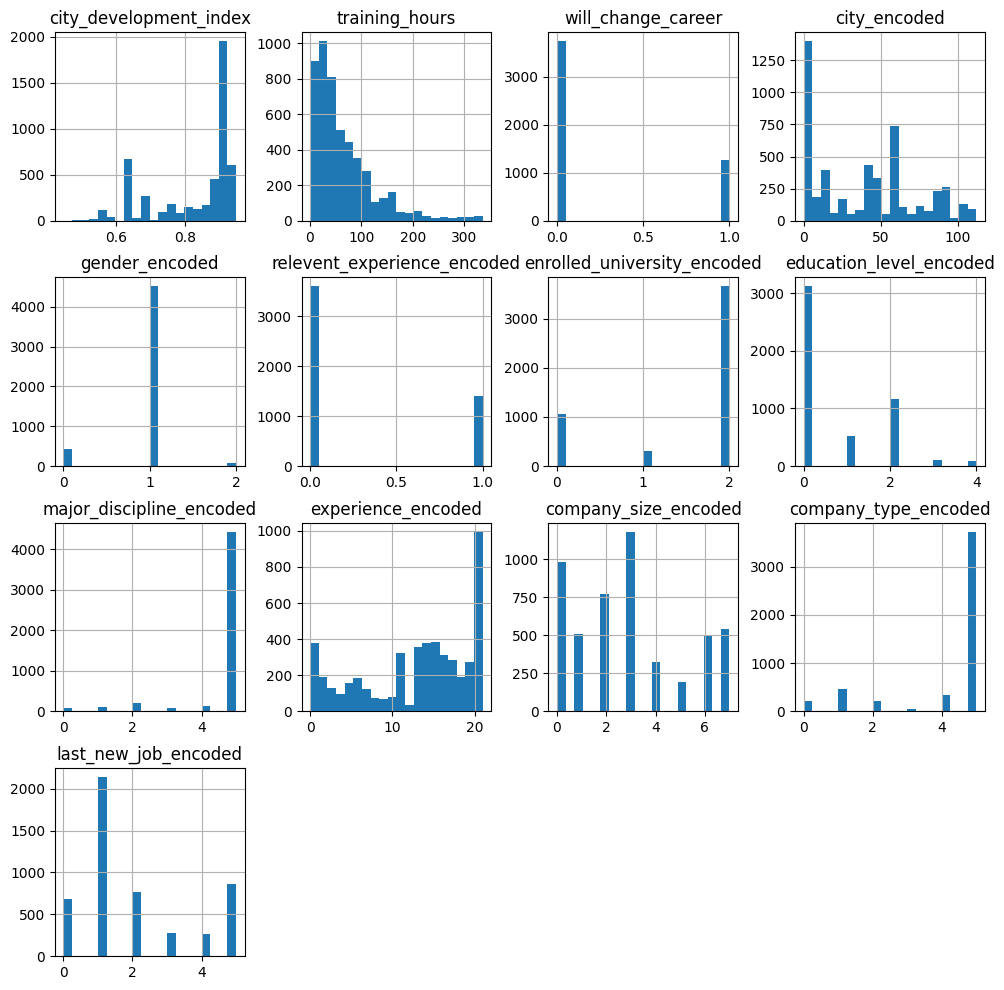

In [ ]:
processed_ds.hist(figsize=(12,12),bins=20)
plt.show()

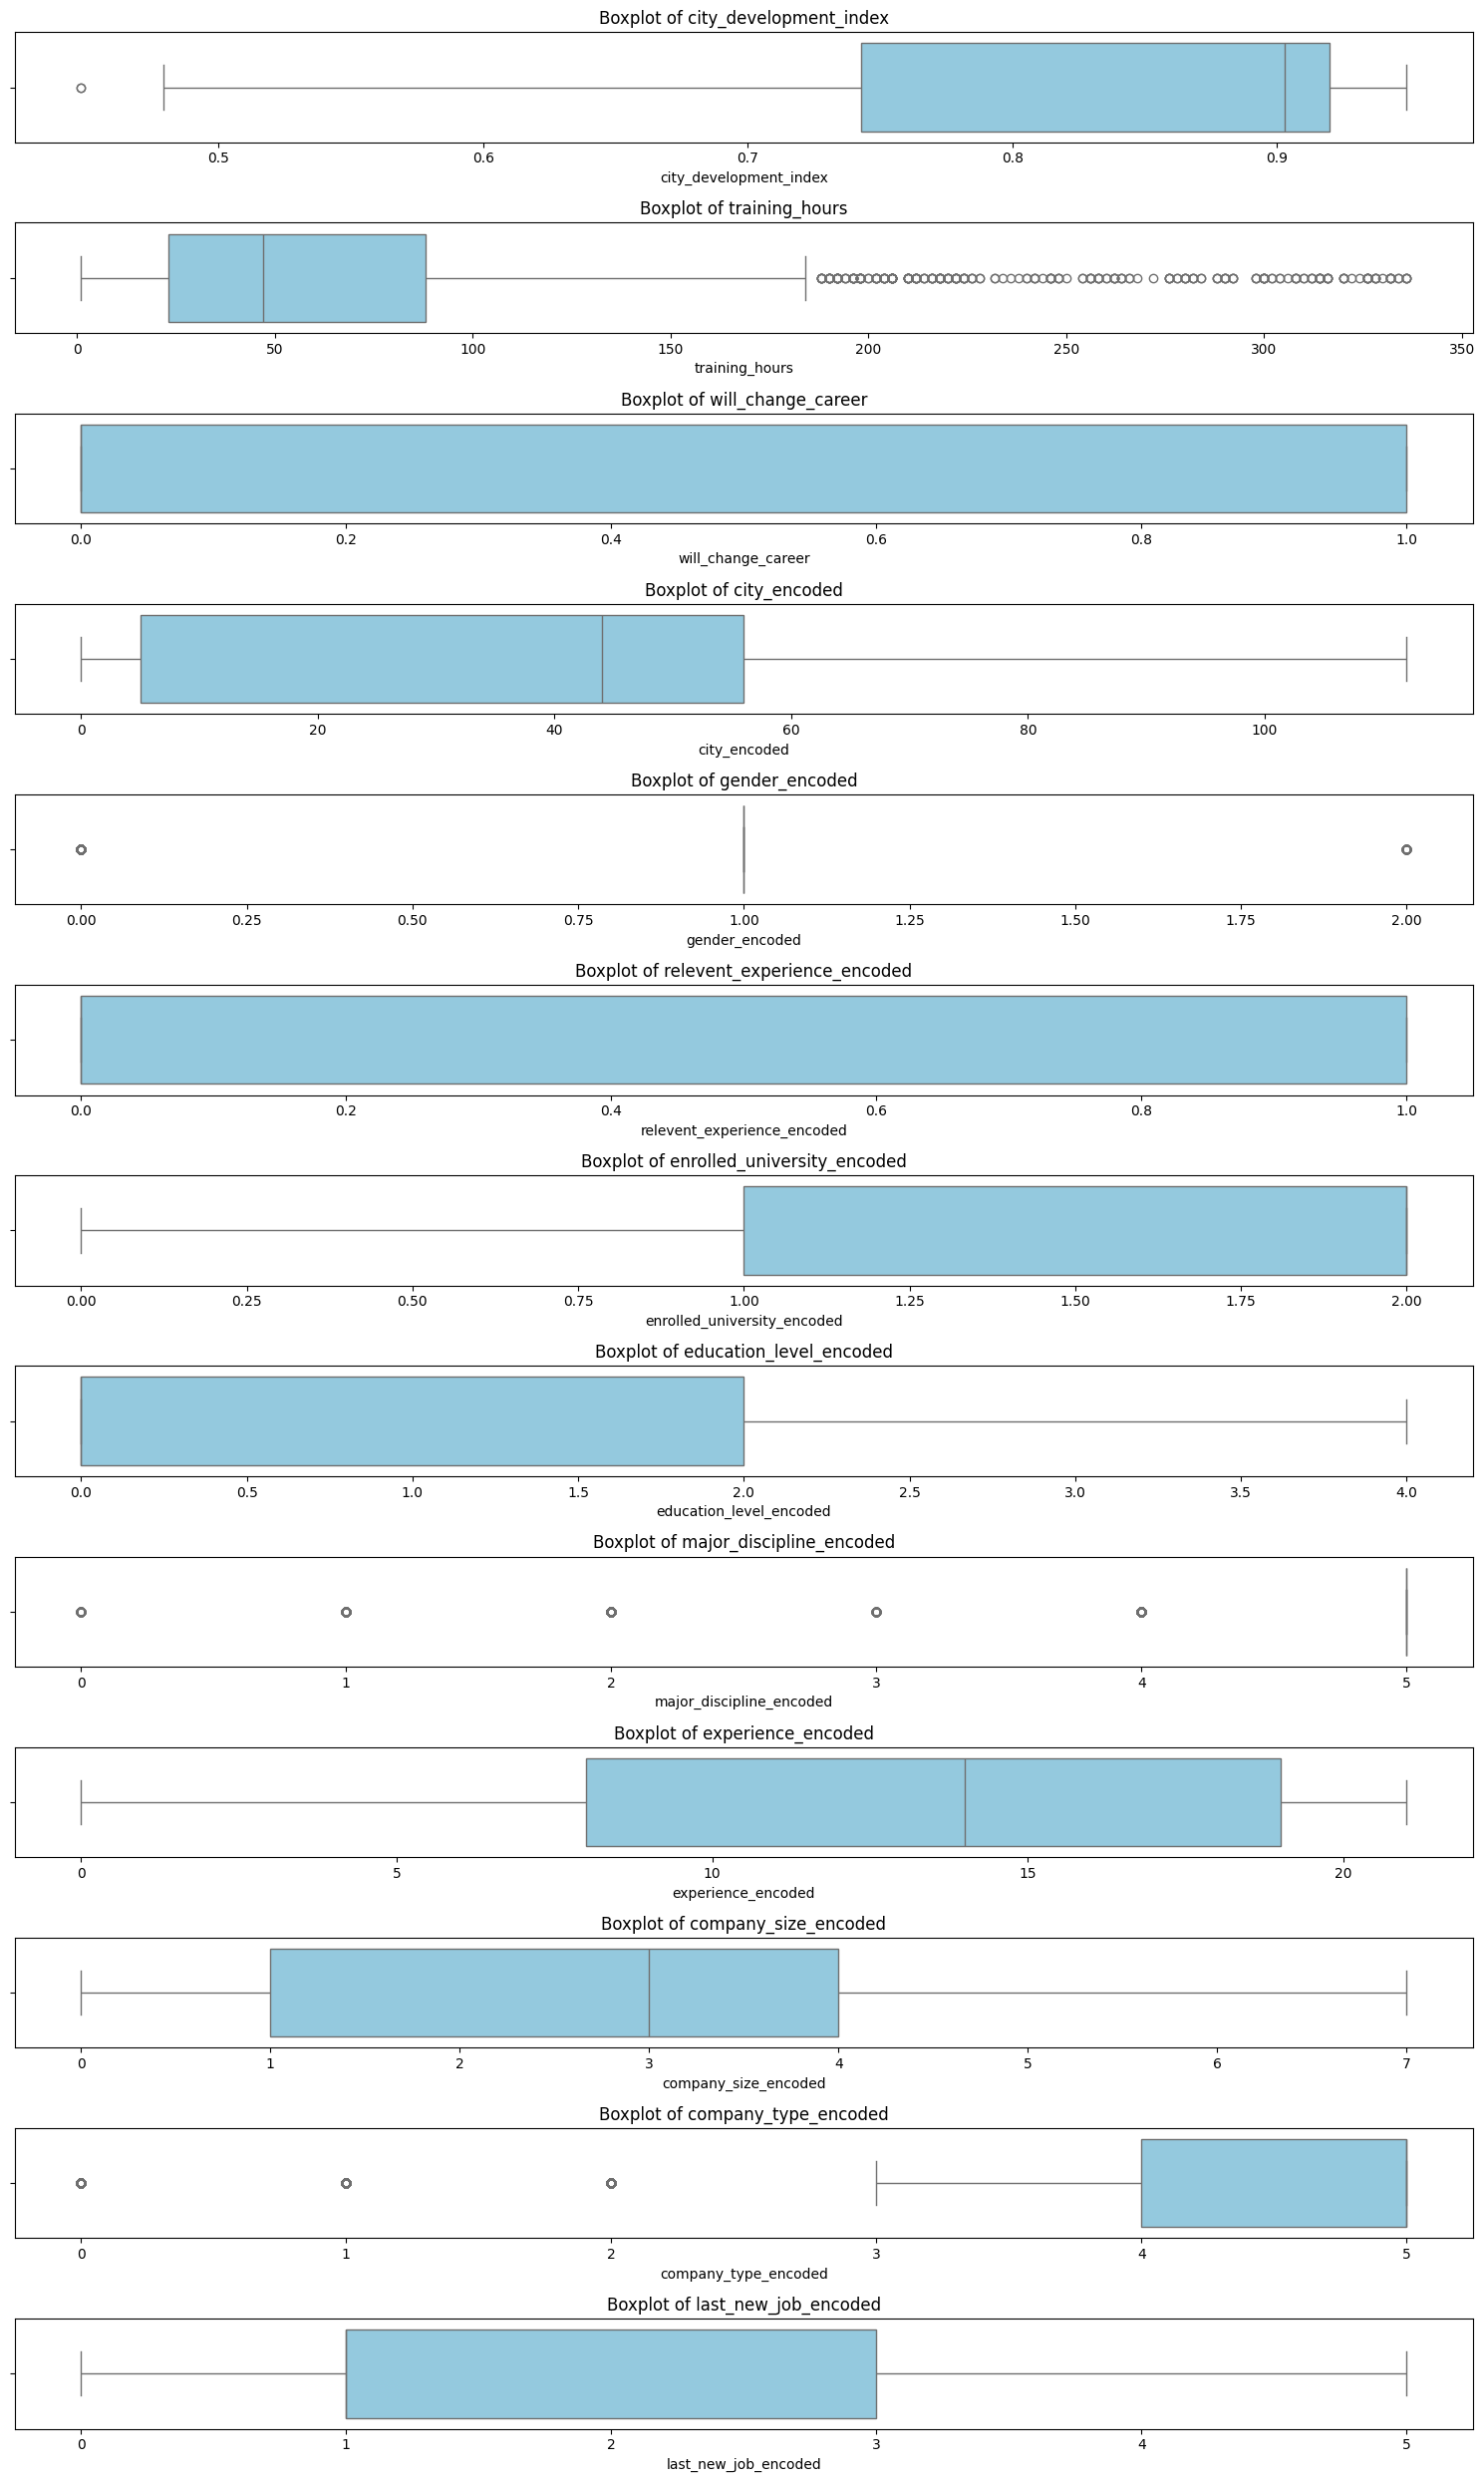

In [ ]:
plt.figure(figsize=(15, 25))

for i, col in enumerate(processed_ds.columns, 1):
    plt.subplot(len(processed_ds.columns), 1, i)
    sns.boxplot(x=processed_ds[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

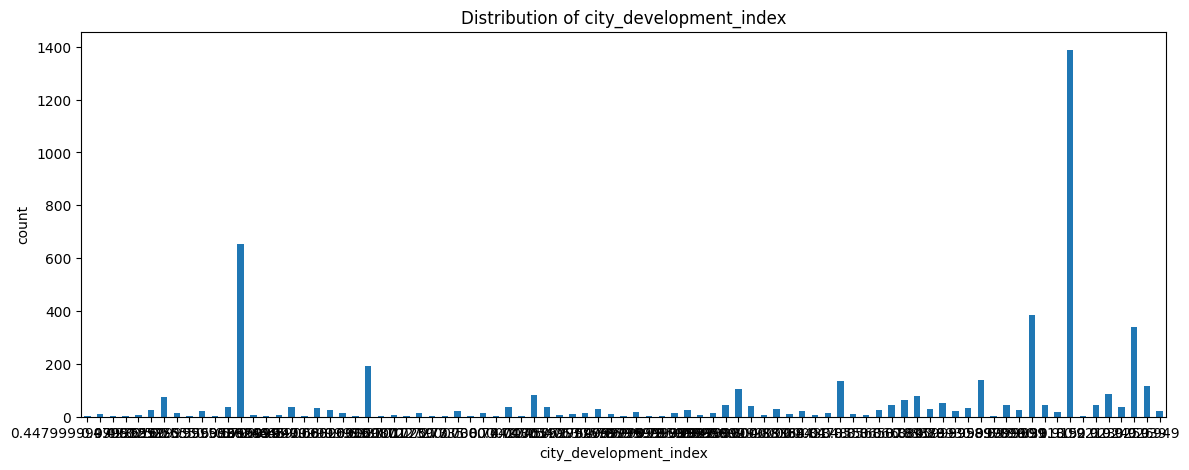

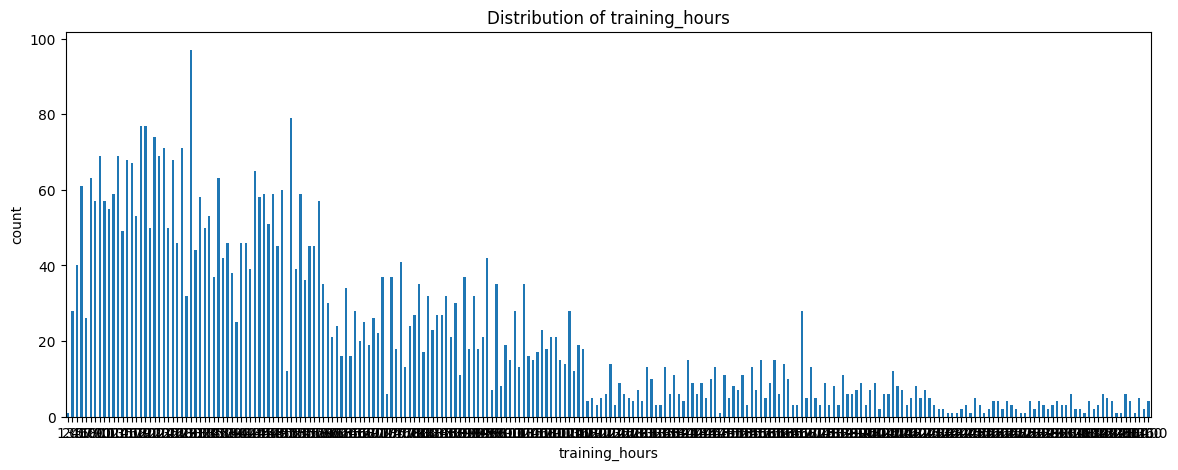

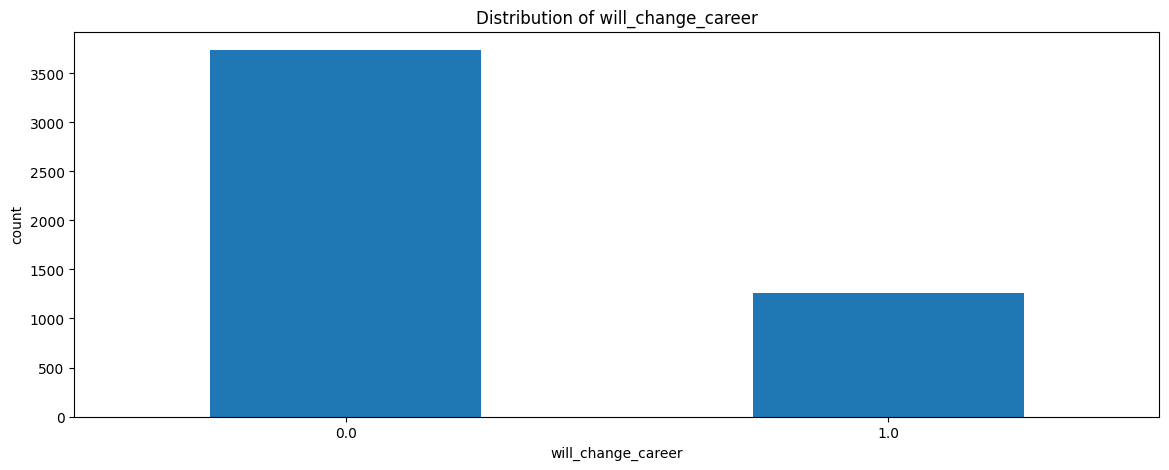

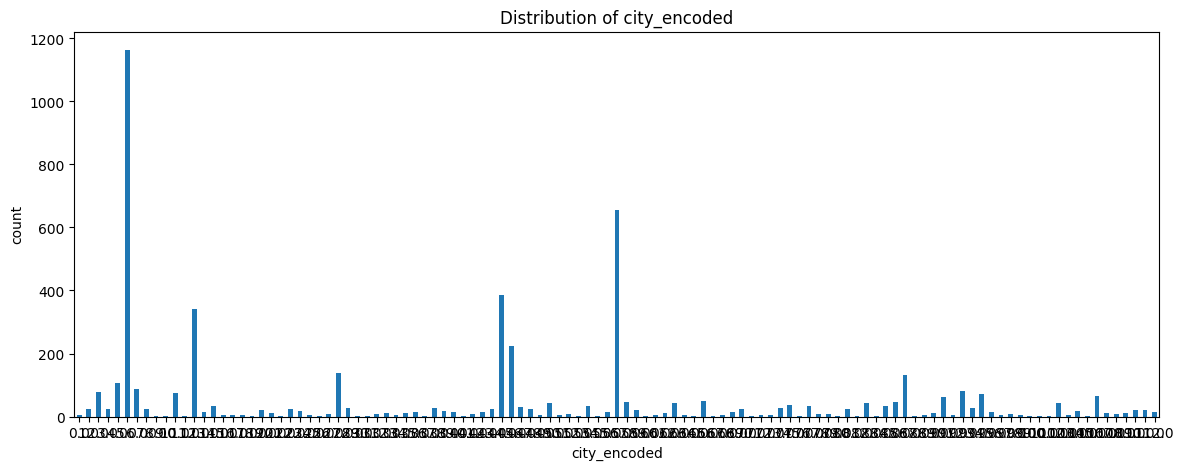

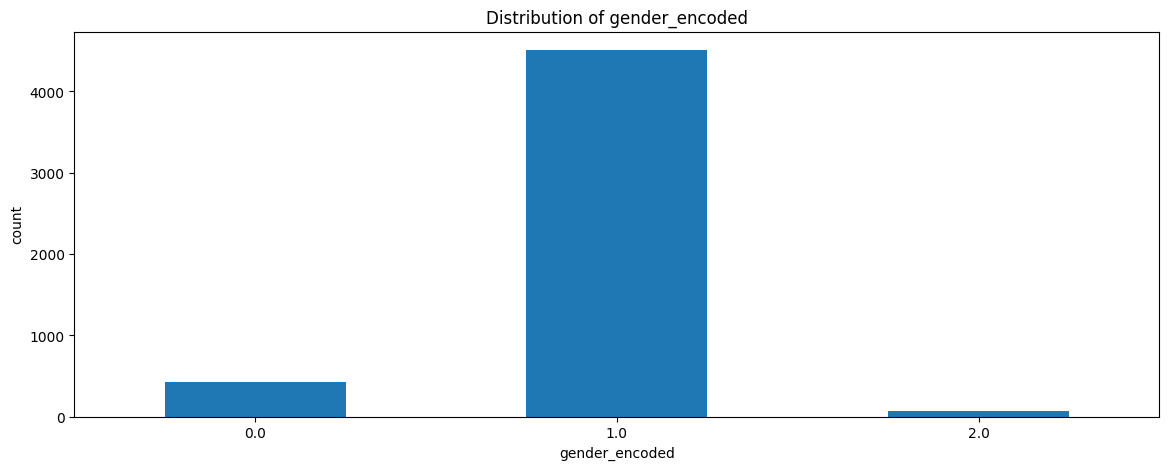

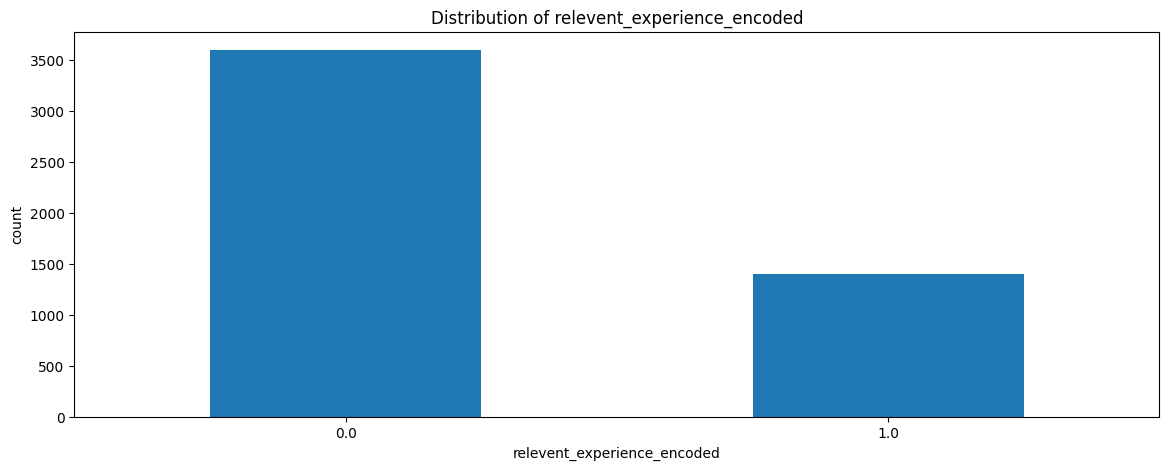

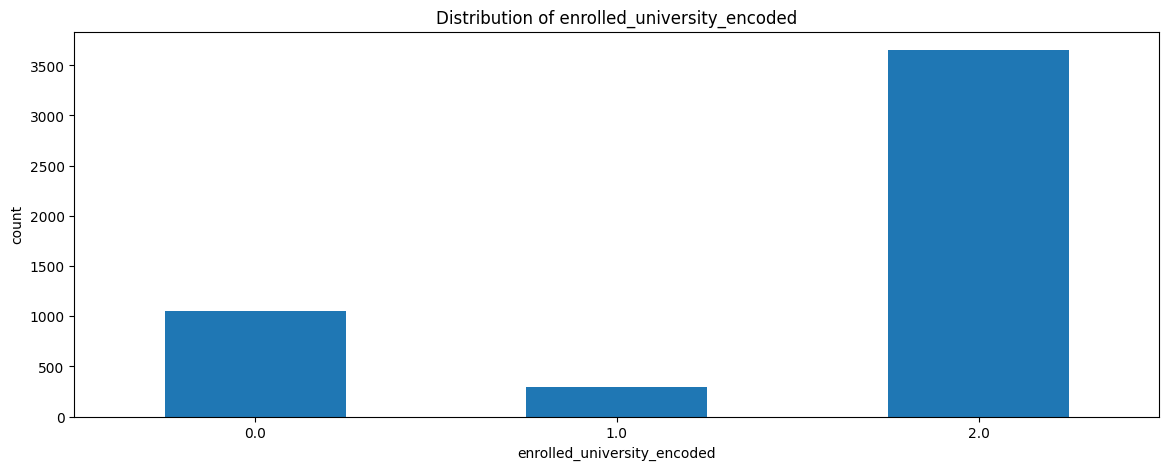

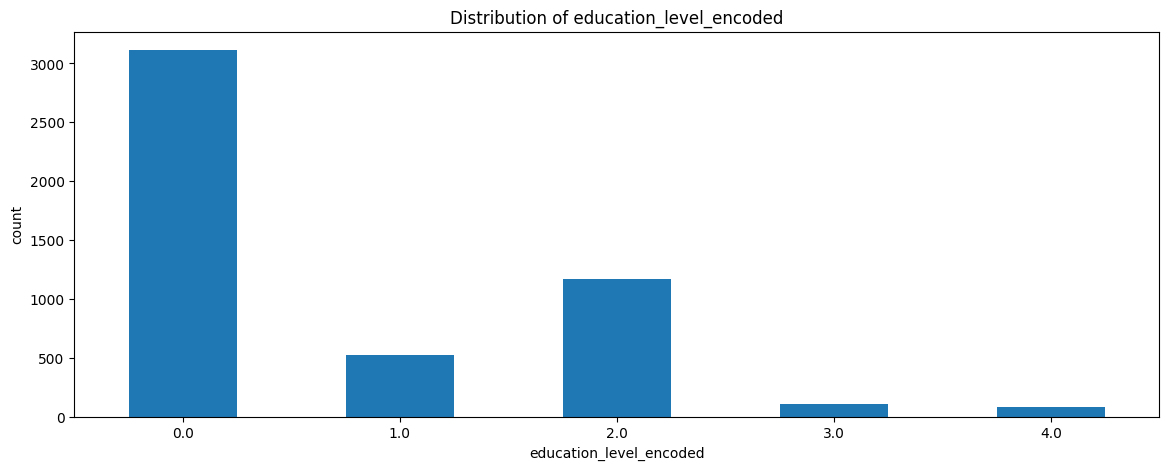

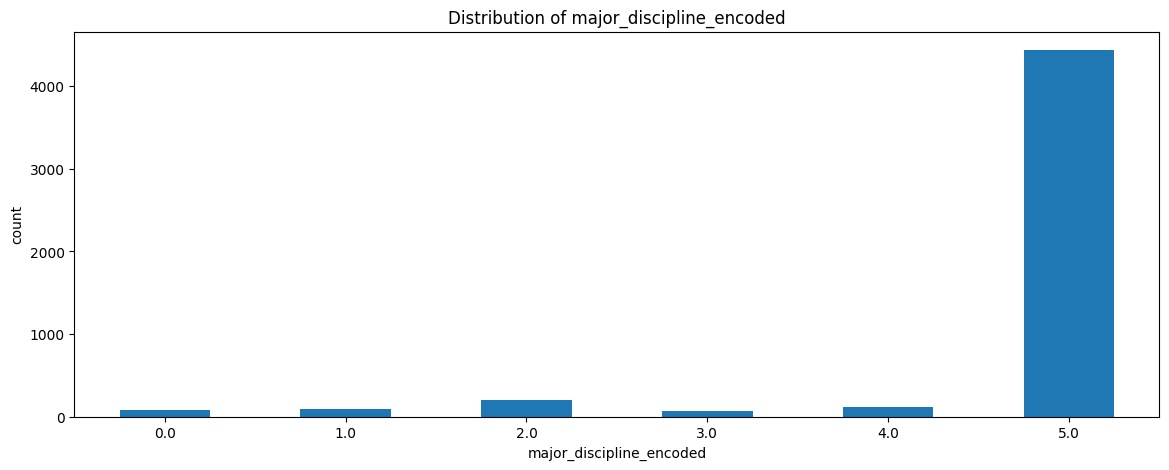

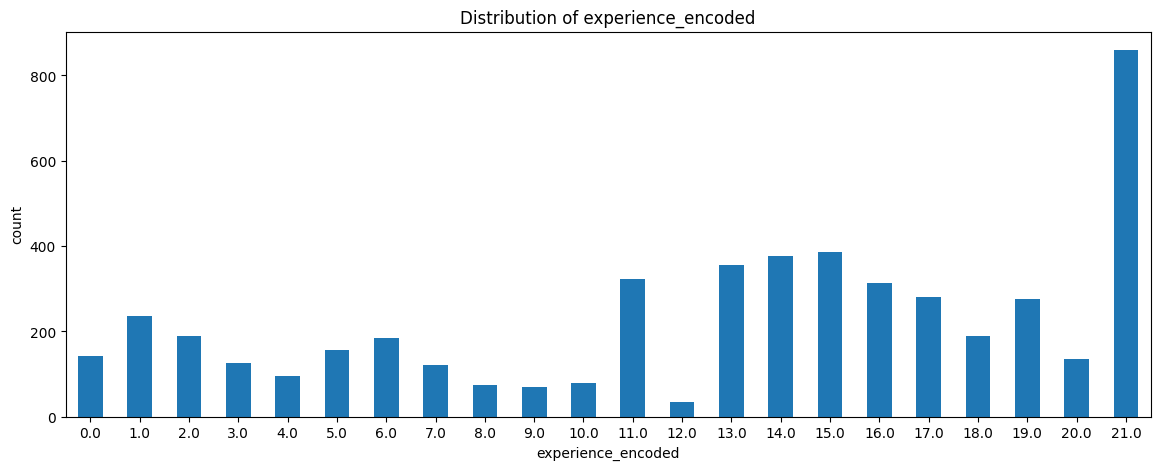

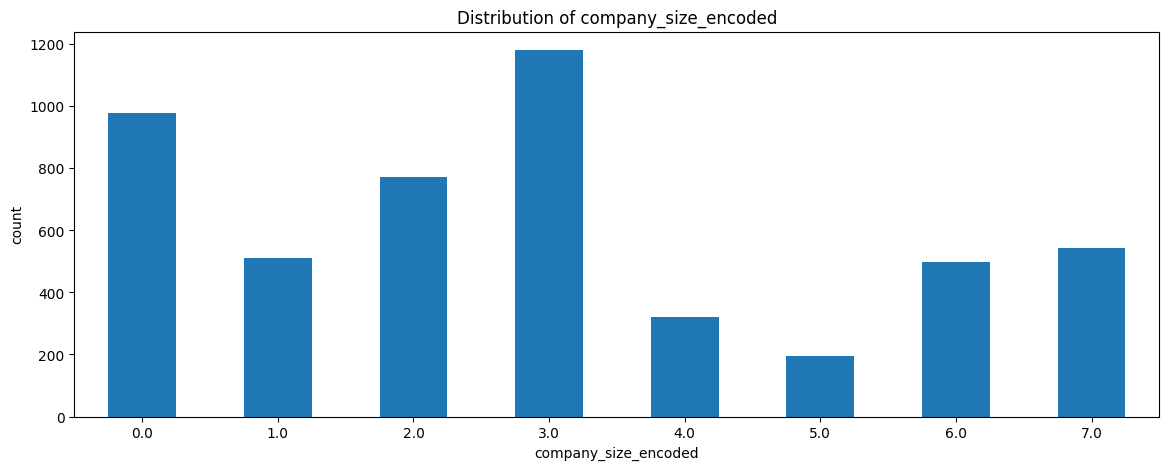

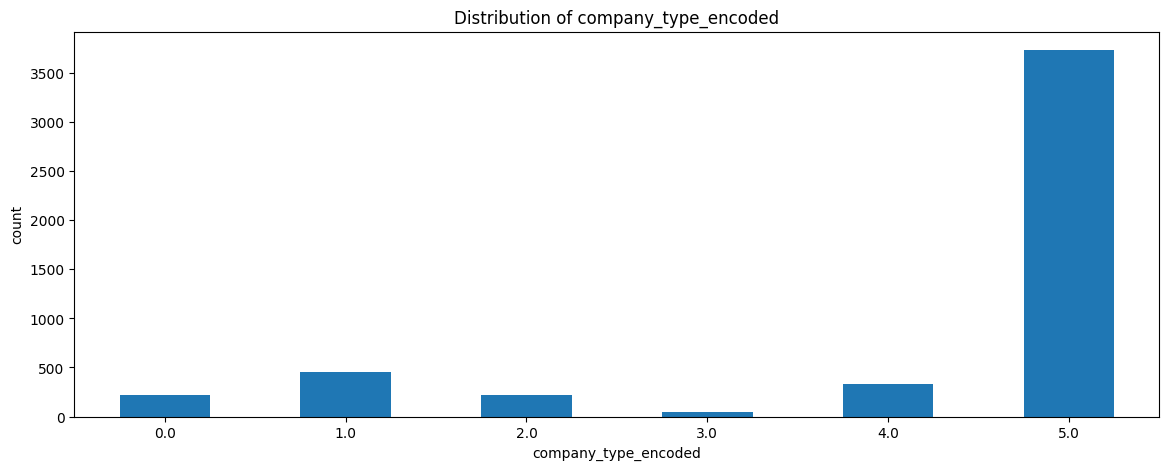

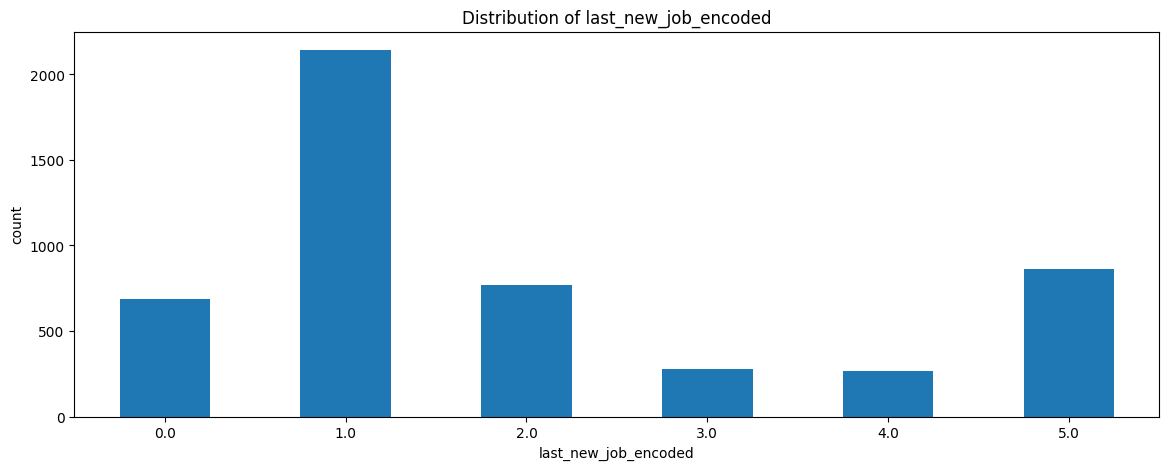

In [ ]:
for col in all_columns:
    plt.title(f'Distribution of {col}')
    processed_ds[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count', figsize = (14,5))
    plt.show()

In [ ]:
correlation_matrix = processed_ds.corr()
correlation_matrix

,city_development_index,training_hours,will_change_career,city_encoded,gender_encoded,relevent_experience_encoded,enrolled_university_encoded,education_level_encoded,major_discipline_encoded,experience_encoded,company_size_encoded,company_type_encoded,last_new_job_encoded
city_development_index,1.000000,0.004717,-0.346808,-0.316671,-0.006688,-0.075128,0.188236,0.073240,-0.108166,0.022934,-0.067058,-0.015557,0.179298
training_hours,0.004717,1.000000,-0.022170,0.008549,-0.004305,-0.020138,0.017729,-0.024048,0.005363,0.005902,0.007181,-0.008928,0.003876
will_change_career,-0.346808,-0.022170,1.000000,0.046992,-0.024385,0.112887,-0.150606,-0.081704,0.040422,0.011752,0.013889,-0.000136,-0.051505
city_encoded,-0.316671,0.008549,0.046992,1.000000,0.003238,0.002909,-0.099966,0.007769,0.091327,-0.028772,0.061907,-0.005358,-0.051831
gender_encoded,-0.006688,-0.004305,-0.024385,0.003238,1.000000,-0.011944,-0.019675,-0.019387,0.020310,0.006583,0.020691,0.008440,-0.012187
relevent_experience_encoded,-0.075128,-0.020138,0.112887,0.002909,-0.011944,1.000000,-0.385714,0.075073,-0.025416,-0.028206,0.007154,0.016362,-0.261735
enrolled_university_encoded,0.188236,0.017729,-0.150606,-0.099966,-0.019675,-0.385714,1.000000,0.055845,-0.072500,0.036122,-0.028610,0.013511,0.237982
education_level_encoded,0.073240,-0.024048,-0.081704,0.007769,-0.019387,0.075073,0.055845,1.000000,0.023491,0.020612,-0.016801,0.002545,0.015577
major_discipline_encoded,-0.108166,0.005363,0.040422,0.091327,0.020310,-0.025416,-0.072500,0.023491,1.000000,0.003972,0.001625,0.036039,-0.015503
experience_encoded,0.022934,0.005902,0.011752,-0.028772,0.006583,-0.028206,0.036122,0.020612,0.003972,1.000000,-0.036283,-0.018819,0.079595


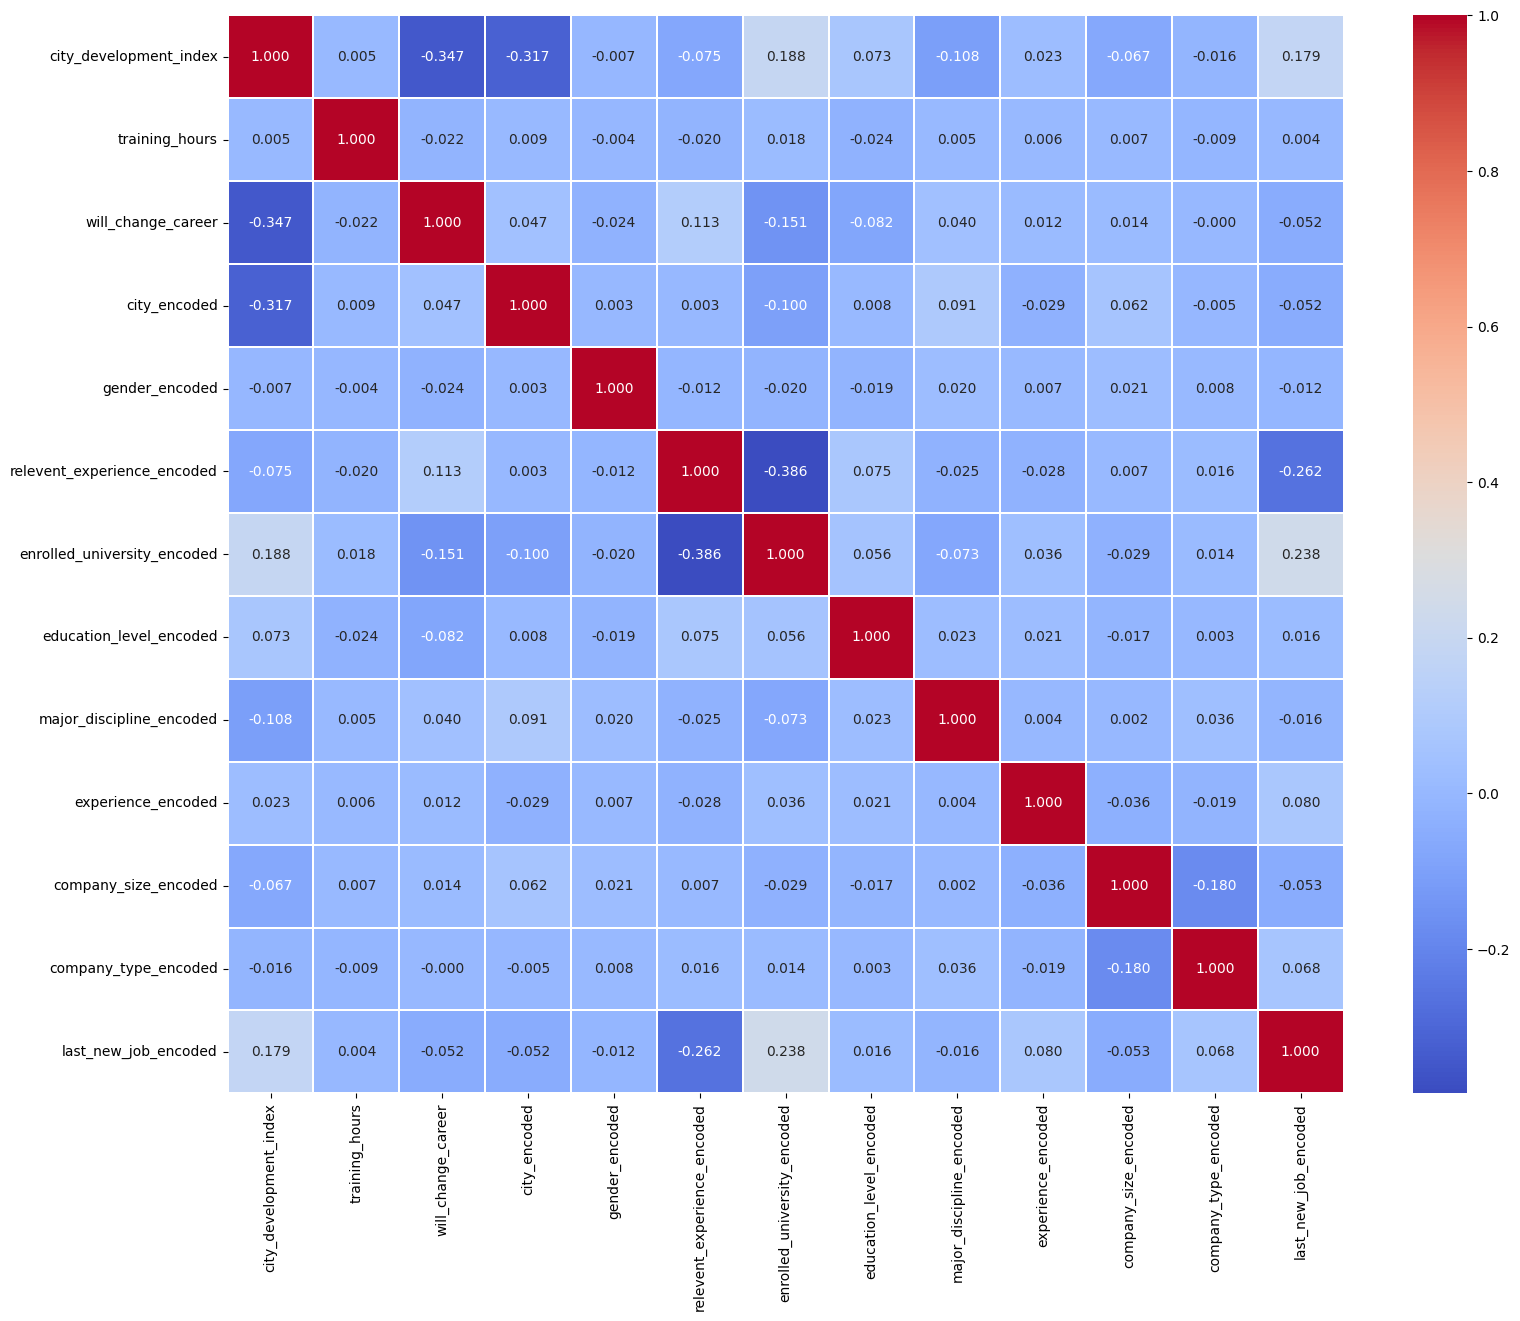

In [ ]:
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

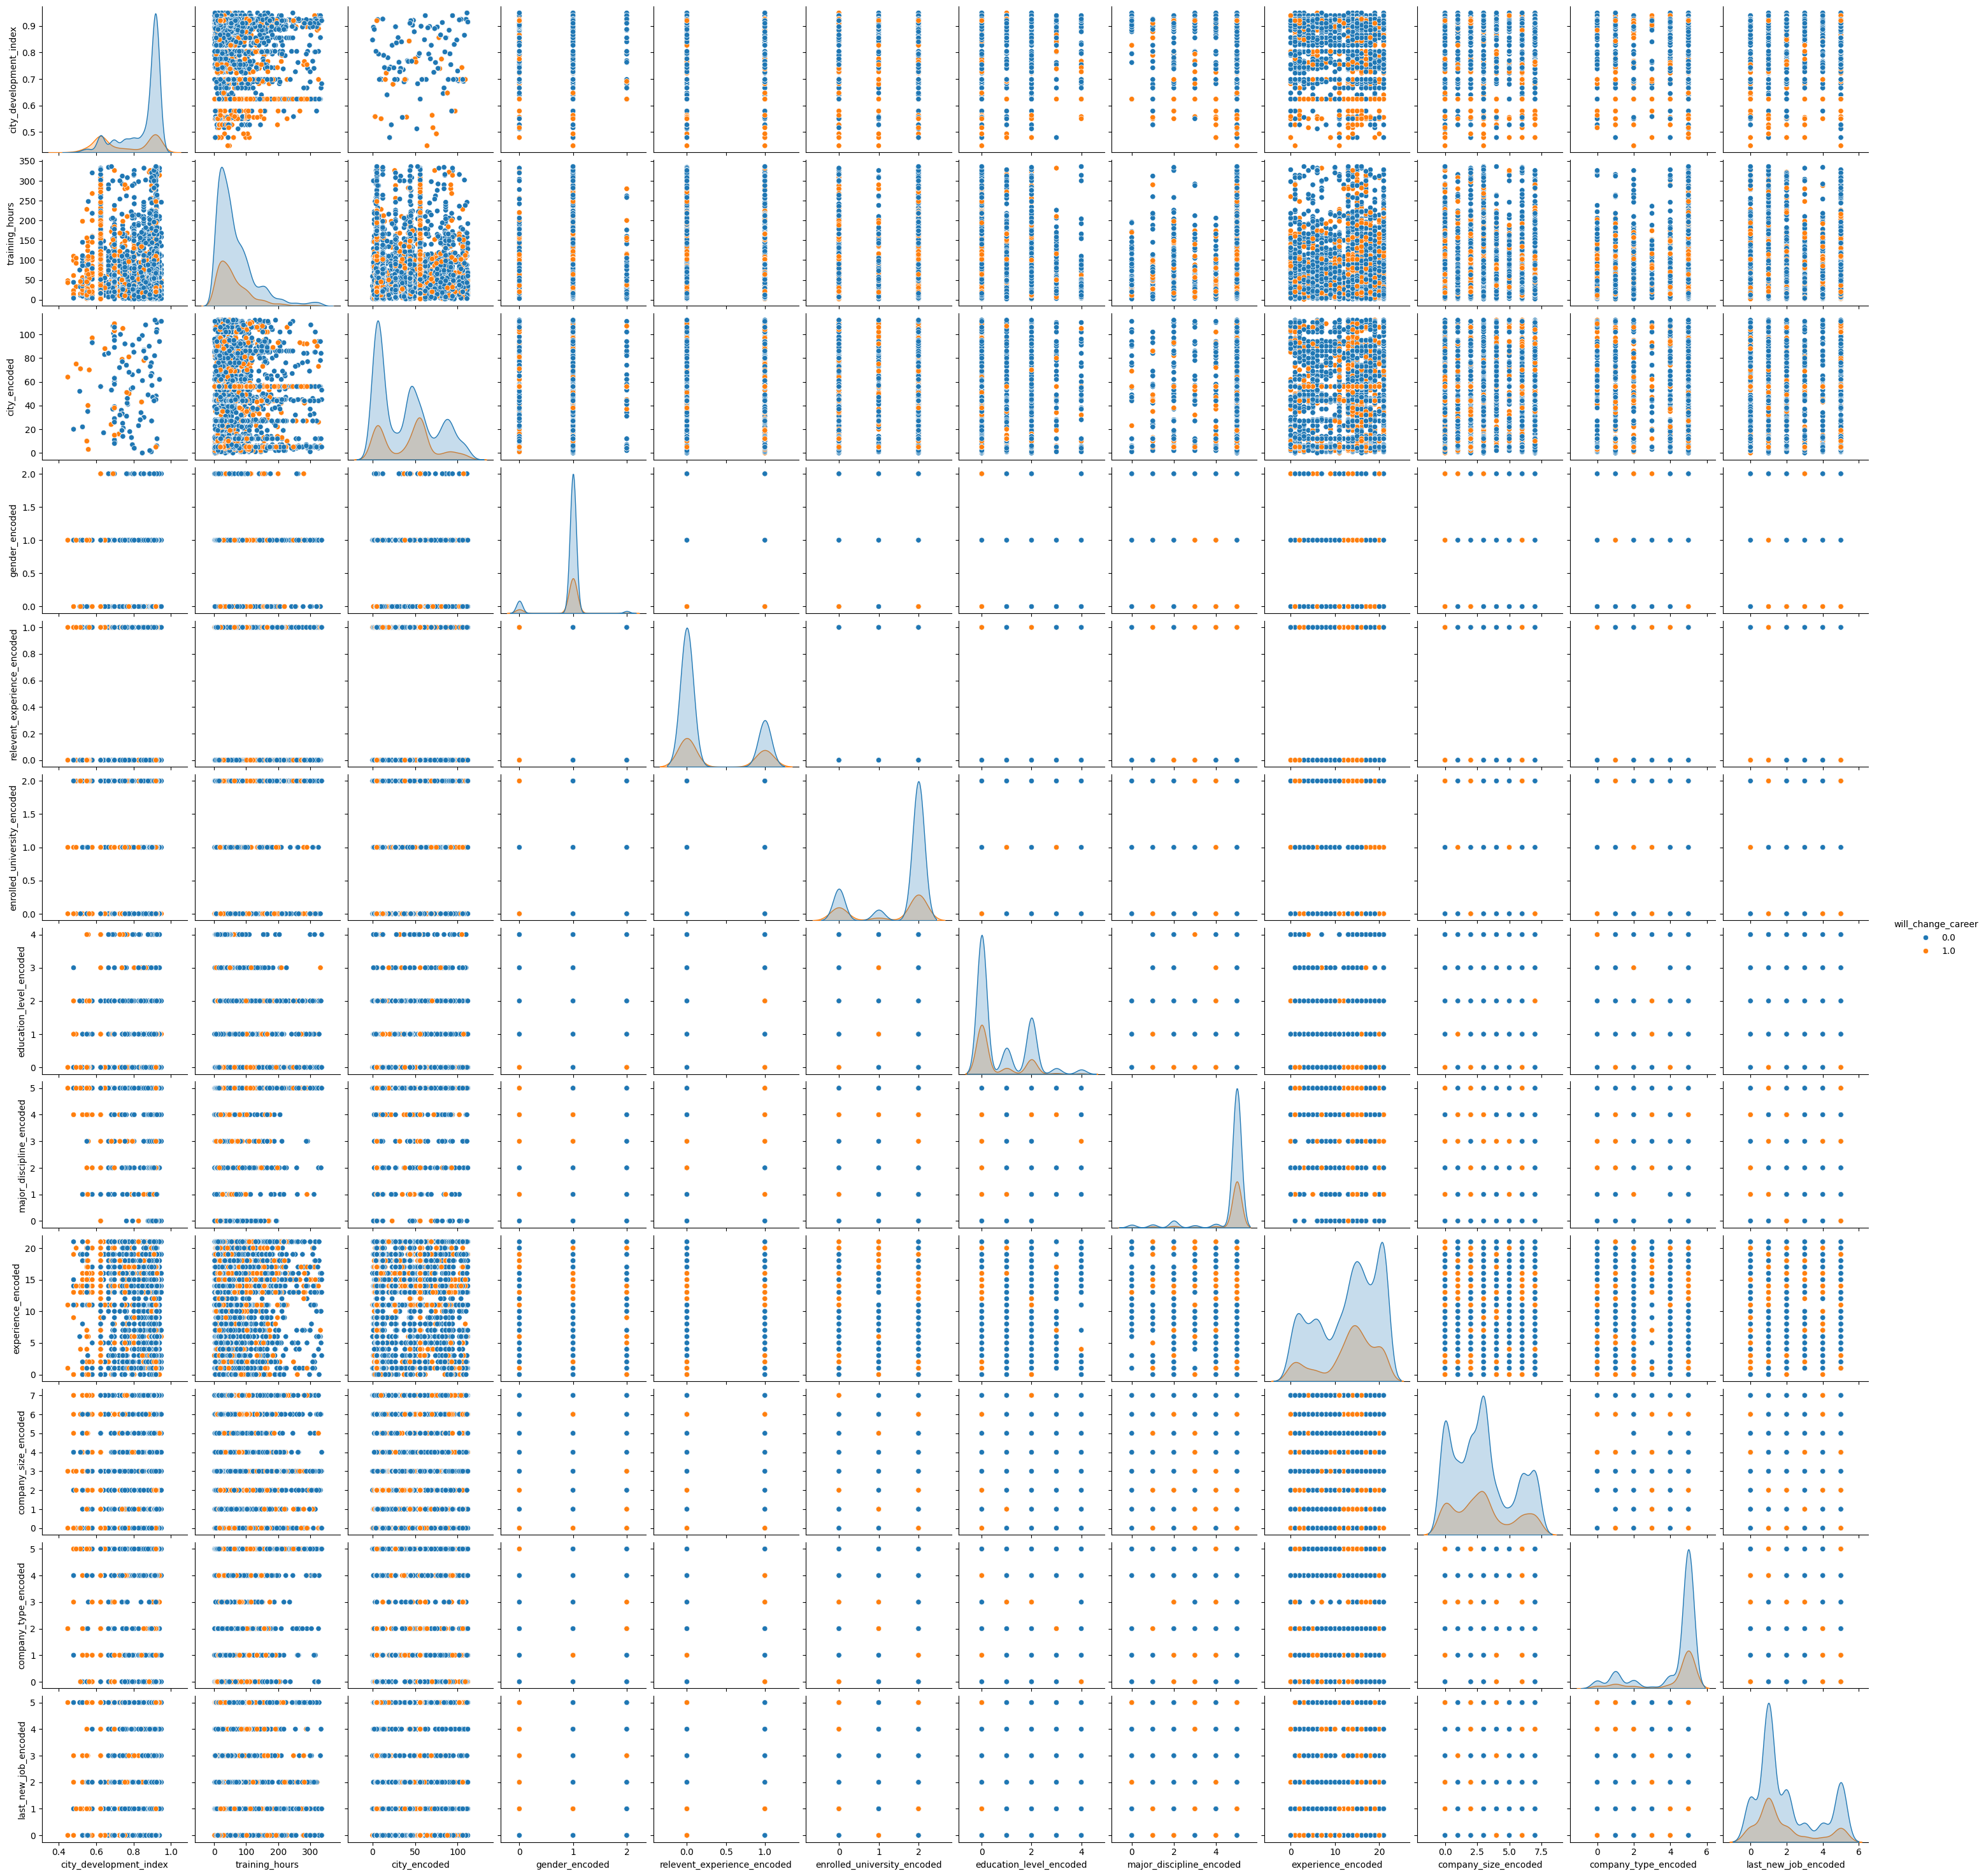

In [ ]:
sns.pairplot(processed_ds, hue='will_change_career')

Check Imbalanced Dataset

In [ ]:
counts = dataset['will_change_career'].value_counts()
print(counts)

will_change_career
0    3738
1    1262
Name: count, dtype: int64


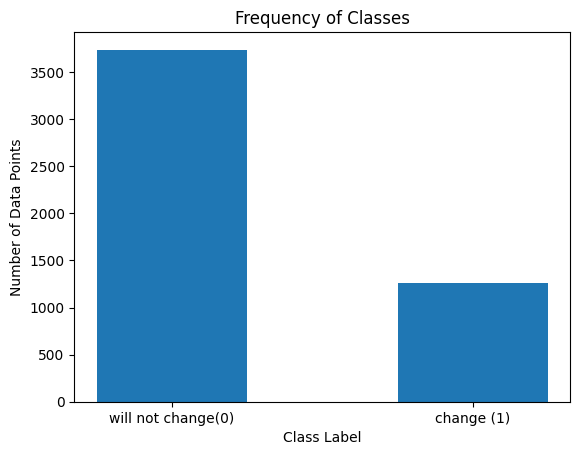

In [ ]:
fig, ax = plt.subplots()

ax.hist(processed_ds['will_change_career'], bins = [-0.5, 0.5, 1.5], rwidth=0.5)

ax.set_title('Frequency of Classes')
ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Data Points')

ax.set_xticks([0, 1])
ax.set_xticklabels(['will not change(0)', 'change (1)'])

plt.show()

# Feature scaling

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
processed_ds[all_columns] = scaler.fit_transform(processed_ds[all_columns])
processed_ds[:50] #for outlier affected data.

,city_development_index,training_hours,will_change_career,city_encoded,gender_encoded,relevent_experience_encoded,enrolled_university_encoded,education_level_encoded,major_discipline_encoded,experience_encoded,company_size_encoded,company_type_encoded,last_new_job_encoded
0,0.096045,-0.169231,1.0,-0.764706,0.0,0.0,0.0,0.0,0.0,0.636364,-0.333333,0.0,0.0
1,-0.717514,0.000000,0.0,0.470588,0.0,1.0,0.0,0.0,0.0,-0.727273,0.000000,0.0,2.0
2,-1.576271,0.553846,0.0,0.235294,0.0,1.0,-2.0,0.0,0.0,0.090909,-1.000000,0.0,-0.5
3,-0.644068,0.076923,1.0,-0.607843,0.0,1.0,0.0,0.0,-4.0,0.545455,1.333333,0.0,-0.5
4,-0.768362,-0.600000,0.0,0.039216,0.0,0.0,0.0,1.0,0.0,0.636364,0.000000,-4.0,1.5
5,-0.785311,-0.353846,1.0,0.137255,0.0,0.0,-1.0,0.0,0.0,-1.090909,-0.333333,0.0,0.0
6,0.096045,-0.353846,0.0,0.019608,0.0,0.0,0.0,0.5,0.0,0.090909,0.000000,-4.0,0.0
7,-0.796610,-0.446154,1.0,0.588235,0.0,0.0,0.0,0.0,0.0,-0.909091,1.000000,0.0,2.0
8,0.096045,-0.015385,1.0,-0.764706,0.0,0.0,0.0,0.0,0.0,0.272727,0.000000,0.0,0.0
9,0.096045,1.169231,0.0,-0.764706,0.0,0.0,0.0,0.0,0.0,-0.545455,-0.333333,0.0,2.0


Test-Train Split

In [ ]:
from sklearn.model_selection import train_test_split

X = processed_ds.drop('will_change_career', axis=1)
y = processed_ds['will_change_career']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3500, 12)
y_train shape: (3500,)
X_test shape: (1500, 12)
y_test shape: (1500,)


Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_original = X_train.copy()
X_test_original = X_test.copy()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models and Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report,precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

Decision Tree

In [ ]:
from sklearn import tree
clf_dt = tree.DecisionTreeClassifier()
clf_dt.fit(X_train, y_train)

dec_tree_score = clf_dt.score(X_test, y_test)

print("Test set accuracy: {:.2f}".format(dec_tree_score))
y_pred = clf_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test set accuracy: 0.69
Accuracy: 0.686

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.78      0.79      1121
         1.0       0.39      0.41      0.40       379

    accuracy                           0.69      1500
   macro avg       0.59      0.59      0.59      1500
weighted avg       0.69      0.69      0.69      1500



KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_score = knn.score(X_test, y_test)

print("Test set accuracy: {:.2f}".format(knn_score))
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test set accuracy: 0.74
Accuracy: 0.74

Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.88      0.84      1121
         1.0       0.48      0.32      0.39       379

    accuracy                           0.74      1500
   macro avg       0.64      0.60      0.61      1500
weighted avg       0.71      0.74      0.72      1500



Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)

logistic_score = clf.score(X_test, y_test)

print("Test set accuracy: {:.2f}".format(logistic_score))
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test set accuracy: 0.78
Accuracy: 0.7753333333333333

Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.95      0.86      1121
         1.0       0.64      0.26      0.37       379

    accuracy                           0.78      1500
   macro avg       0.71      0.60      0.62      1500
weighted avg       0.75      0.78      0.74      1500



In [ ]:
import numpy as np

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

import pandas as pd
from matplotlib import pyplot as plt


Neural Network

In [ ]:
model = Sequential([
  Dense(128, activation='relu'),
  Dense(1, activation="sigmoid")
])

# Compile model
from tensorflow.keras.losses import BinaryCrossentropy

model.compile(optimizer=Adam(0.001),
              loss=BinaryCrossentropy(),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs = 10, batch_size=128)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes,zero_division=0))

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6465 - loss: 0.6524
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7428 - loss: 0.5378
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7560 - loss: 0.5014
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7614 - loss: 0.4941
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7836 - loss: 0.4743
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7706 - loss: 0.4906
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7640 - loss: 0.5092
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7782 - loss: 0.4889
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7721 - loss: 0.4919
Epoch 10/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7829 - loss: 0.4740
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8013 - loss: 0.4775
Test Accuracy: 0.7833
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
 

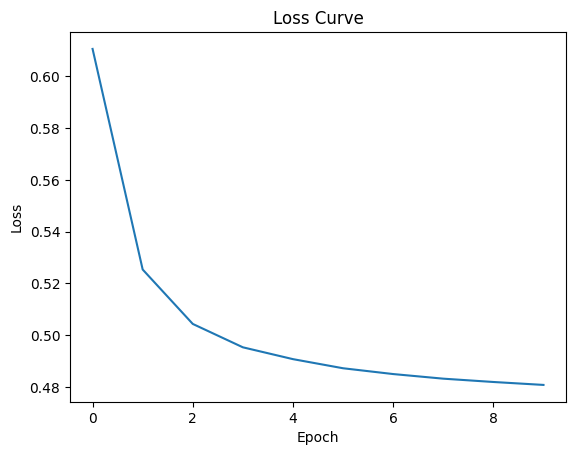

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8013 - loss: 0.4775
Testing Accuracy: 78.33%


In [ ]:
plt.plot(history.history['loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

neural_network_score = model.evaluate(X_test, y_test)[1]
print(f"Testing Accuracy: {round(neural_network_score * 100, 2)}%")

#K-Means Clustering

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#Getting Cluster number

In [ ]:
k_range = range(1,10)
SSE = []
for k in k_range:
  km = KMeans(n_clusters= k)
  km.fit(X_train)
  SSE.append(km.inertia_)
SSE

[41999.99999999998,
 37572.749213514464,
 34757.200259042285,
 32574.07435584295,
 29944.462689970398,
 28119.837745880995,
 28121.97170555619,
 26161.851800385182,
 24665.662692597987]

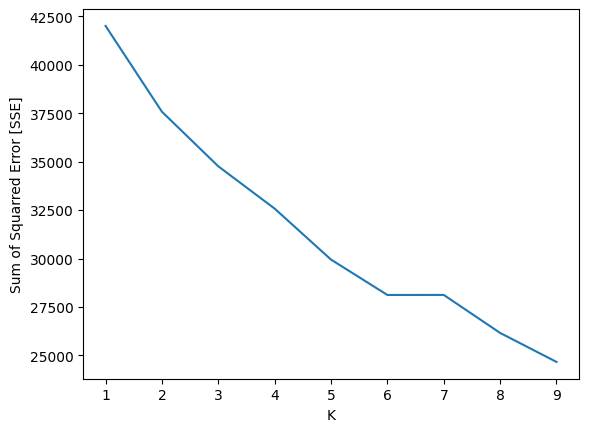

In [ ]:
plt.xlabel("K")
plt.ylabel("Sum of Squarred Error [SSE]")
plt.plot(k_range,SSE)

#Plotting Clusters

<class 'pandas.core.frame.DataFrame'>


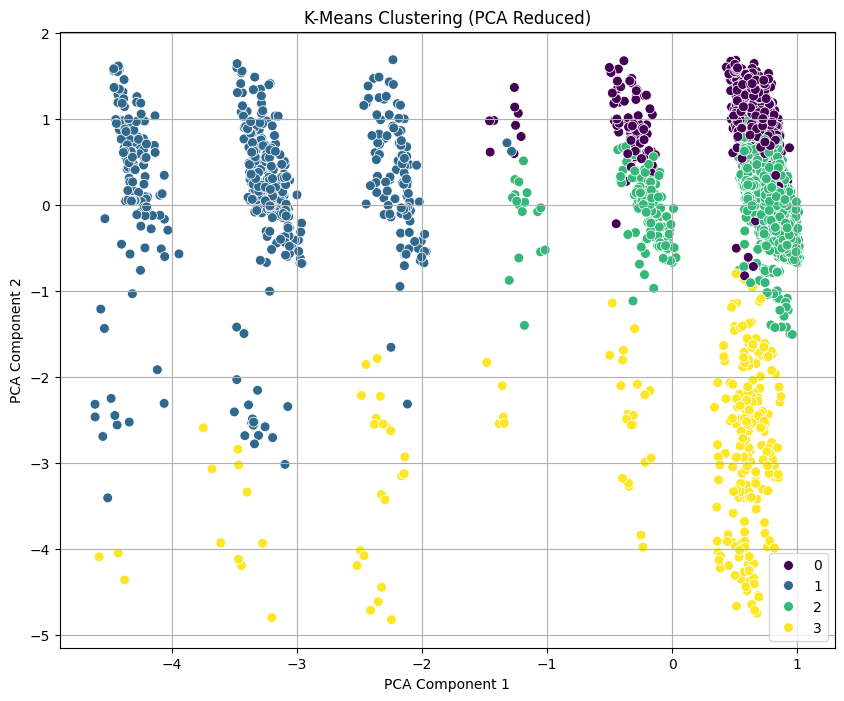

In [ ]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
y_predicted = km.fit_predict(X_train_original)

X_train_clustered = X_train_original.copy()

print(type(X_train_clustered))

X_train_clustered['cluster'] = y_predicted

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_clustered.drop('cluster', axis=1))

X_train_clustered['pca1'] = X_train_pca[:, 0]
X_train_clustered['pca2'] = X_train_pca[:, 1]


plt.figure(figsize=(10, 8))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=X_train_clustered, palette='viridis', s=50)
plt.title('K-Means Clustering (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

#Evaluating K-Means model

In [ ]:
km.fit(X_test_original)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [ ]:
km.cluster_centers_

array([[-0.38085825,  0.27961443, -0.12489661, -0.06947891,  0.20223325,
        -0.03225806,  0.39330025, -0.02605459, -0.09846605, -0.09057072,
        -0.08064516,  0.6426799 ],
       [-0.66362143,  0.31107474,  0.05645946, -0.07092199,  0.64184397,
        -1.88297872,  0.30673759, -0.03546099, -0.07962605, -0.02955083,
        -0.13120567,  0.12588652],
       [-0.38421858,  0.28273733, -0.08577612, -0.08695652,  0.25083612,
        -0.41471572,  0.39966555, -0.18729097, -0.10063849,  0.25083612,
        -3.95652174,  0.41137124],
       [-0.09839508,  0.2987066 , -0.24466424, -0.16814159,  0.33628319,
        -0.33628319,  0.34513274, -3.49557522, -0.09332261, -0.02359882,
        -0.49557522,  0.58849558]])

In [ ]:
predictions_km = km.labels_
print("Prediction for the KMeans Cluster")
print(predictions_km, len(predictions_km))
print(y_test)

Prediction for the KMeans Cluster
[2 0 1 ... 1 0 2] 1500
2700    0.0
1316    1.0
191     0.0
1056    0.0
2503    0.0
       ... 
4339    1.0
3189    1.0
1574    0.0
2125    0.0
1033    1.0
Name: will_change_career, Length: 1500, dtype: float64


#K means performance without scaling

In [ ]:
pd.crosstab(predictions_km, y_test)

will_change_career,0.0,1.0
row_0,,
0,628,178
1,174,108
2,230,69
3,89,24


In [ ]:
km_performance = np.mean(predictions_km==y_test)
print("Performance of the KMeans Cluster {:.2f}".format(km_performance))

Performance of the KMeans Cluster 0.49


#Demo K-Means

In [ ]:
import numpy as np
num_rows_to_show = 10
random_indices = np.random.choice(X_test_original.index, size=num_rows_to_show, replace=False)

print(f"Showing K-Means cluster assignment and original 'y' label for {num_rows_to_show} random rows from the test set:\n")

test_index_list = X_test_original.index.tolist()

for i, original_index in enumerate(random_indices):
    position_in_test_set = test_index_list.index(original_index)

    example_row = X_test_original.loc[original_index]
    original_y = y_test.loc[original_index]
    predicted_cluster = predictions_km[position_in_test_set]

    print(f"--- Random Row {i+1} (Original Index: {original_index}) ---")
    print(f"Original 'y' label: {original_y}")
    print(f"K-Means Cluster Assignment: Cluster {predicted_cluster}")
    print("-" * 20)

Showing K-Means cluster assignment and original 'y' label for 10 random rows from the test set:

--- Random Row 1 (Original Index: 4141) ---
Original 'y' label: 0.0
K-Means Cluster Assignment: Cluster 1
--------------------
--- Random Row 2 (Original Index: 2142) ---
Original 'y' label: 0.0
K-Means Cluster Assignment: Cluster 0
--------------------
--- Random Row 3 (Original Index: 4382) ---
Original 'y' label: 0.0
K-Means Cluster Assignment: Cluster 2
--------------------
--- Random Row 4 (Original Index: 87) ---
Original 'y' label: 0.0
K-Means Cluster Assignment: Cluster 1
--------------------
--- Random Row 5 (Original Index: 2429) ---
Original 'y' label: 0.0
K-Means Cluster Assignment: Cluster 0
--------------------
--- Random Row 6 (Original Index: 2022) ---
Original 'y' label: 0.0
K-Means Cluster Assignment: Cluster 0
--------------------
--- Random Row 7 (Original Index: 1317) ---
Original 'y' label: 0.0
K-Means Cluster Assignment: Cluster 0
--------------------
--- Random Row 8

#K-Means performance with scaling

In [ ]:
km.fit(X_test)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [ ]:
km.cluster_centers_

array([[ 0.08264052,  0.01586729, -0.08209376, -3.14864292,  0.18958188,
         0.05062915,  0.16543655, -0.20699261, -0.03485896, -0.05658302,
        -0.11286401,  0.04845561],
       [ 0.08606934,  0.0251417 , -0.04386403,  0.29203731, -0.18037124,
         0.24932335,  0.12393203, -0.05253466,  0.01204928,  0.48157071,
        -2.14884029, -0.03870222],
       [ 0.10707486,  0.01927769, -0.05604676,  0.26492606, -0.47077968,
         0.48376359, -0.02298938,  0.0383538 ,  0.00466708, -0.08614504,
         0.44886659,  0.37957632],
       [-0.26030033,  0.00403439,  0.15018589,  0.31250982,  1.19151012,
        -1.05227424,  0.15267111,  0.07387883, -0.0331769 , -0.01363529,
         0.29074946, -0.62079314]])

In [ ]:
predictions_km = km.labels_
print("Prediction for the KMeans Cluster")
print(predictions_km, len(predictions_km))
print(y_test)

Prediction for the KMeans Cluster
[1 2 3 ... 0 2 1] 1500
2700    0.0
1316    1.0
191     0.0
1056    0.0
2503    0.0
       ... 
4339    1.0
3189    1.0
1574    0.0
2125    0.0
1033    1.0
Name: will_change_career, Length: 1500, dtype: float64


In [ ]:
pd.crosstab(predictions_km, y_test)

will_change_career,0.0,1.0
row_0,,
0,103,41
1,203,55
2,558,147
3,257,136


In [ ]:
km_performance_with_scaling = np.mean(predictions_km==y_test)
print("Performance of the K-Means Cluster After Scaling {:.2f}".format(km_performance_with_scaling))

Performance of the K-Means Cluster After Scaling 0.11


#Model selection/Comparison analysis


#Prediction accuracy Bar-plot


/tmp/ipython-input-2964555599.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


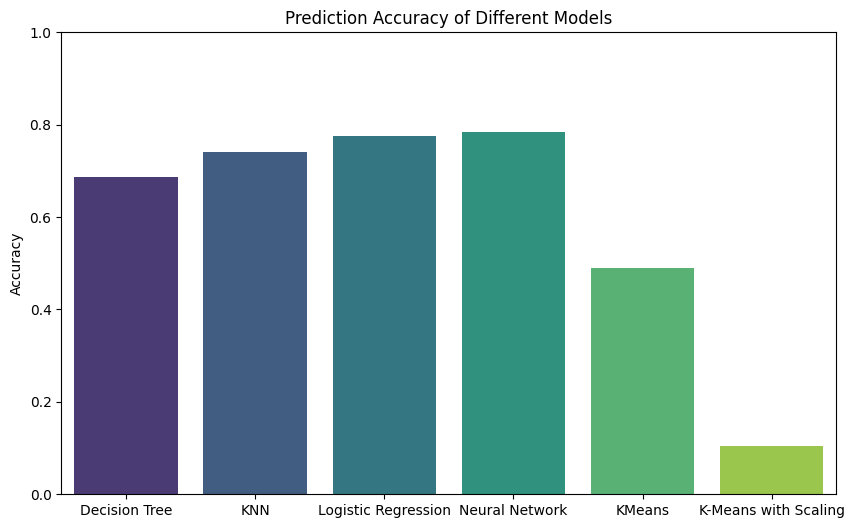

In [ ]:
model_accuracies = {
    'Decision Tree': dec_tree_score,
    'KNN': knn_score,
    'Logistic Regression': logistic_score,
    'Neural Network': neural_network_score,
    'KMeans': km_performance,
    'K-Means with Scaling': km_performance_with_scaling
}

models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy of Different Models')
plt.ylim(0, 1.0)
plt.show()

In [ ]:
models = {
    "Logistic Regression": clf,
    "Decision tree": clf_dt,
    "Neural Network": model,
    "KNN": knn
}


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7787 - loss: 0.4866
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


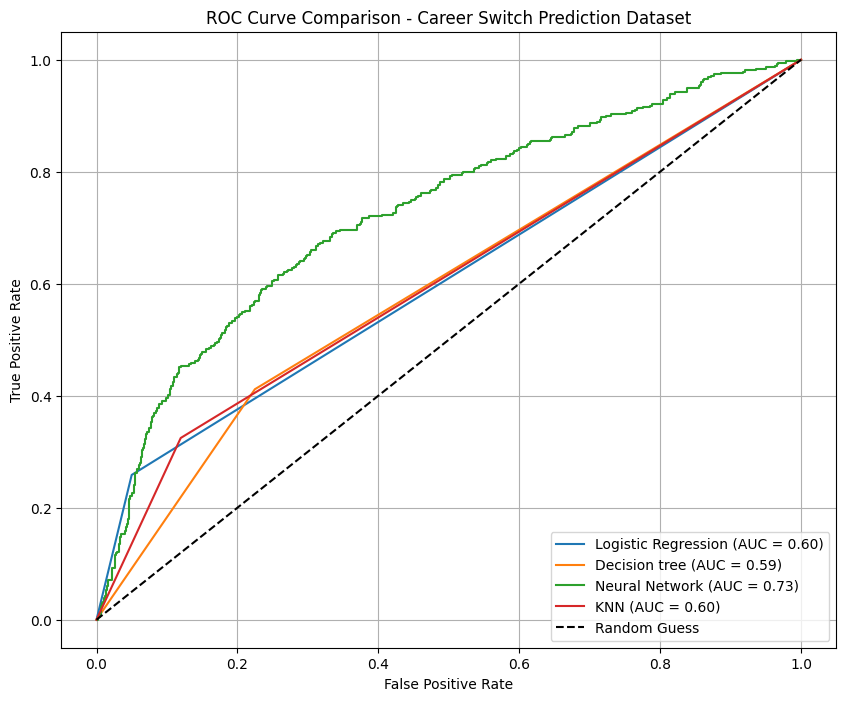

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)

    # Predict probabilities for class 1 (survived)
    y_probs = model.predict(X_test)

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Career Switch Prediction Dataset")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


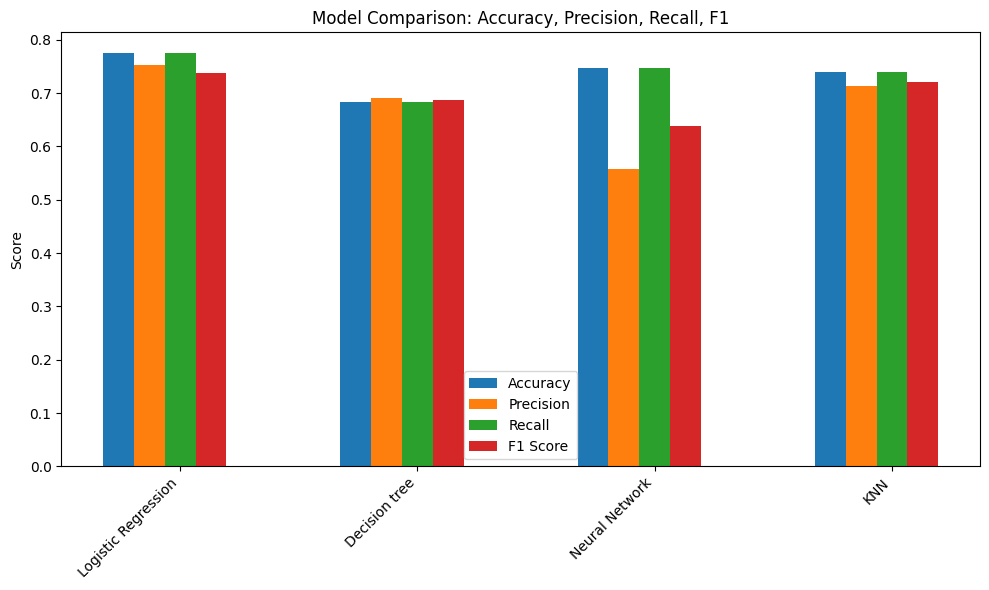

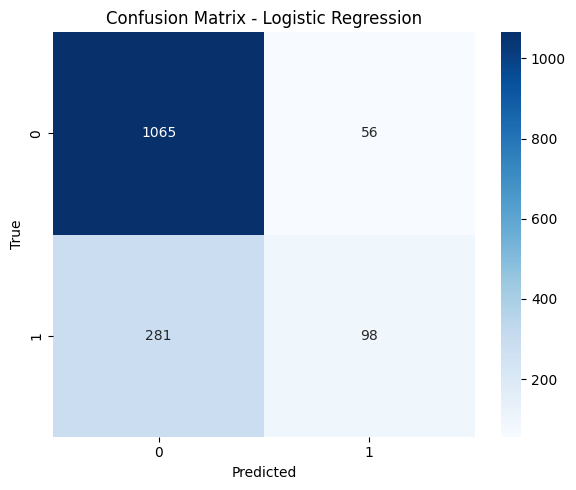

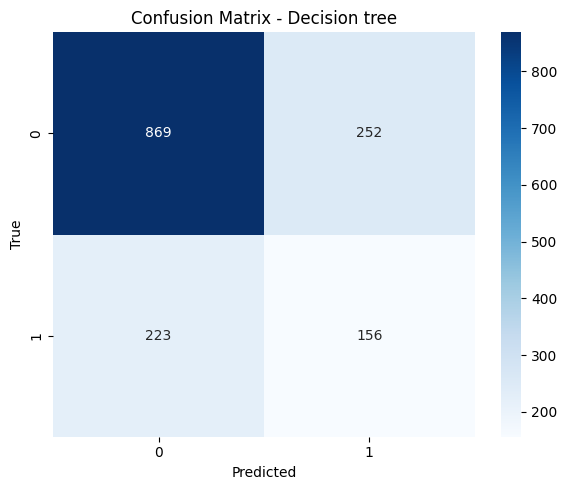

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


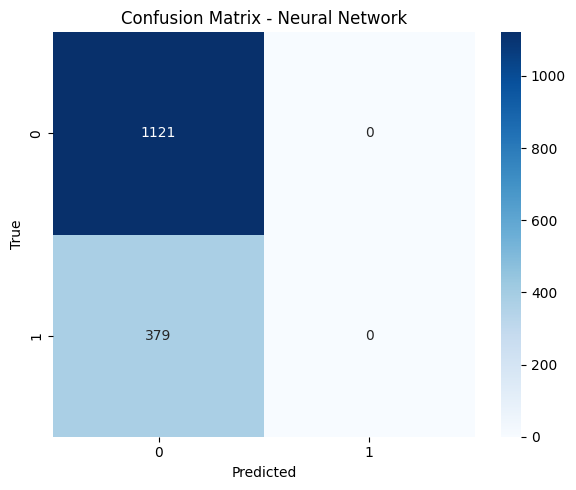

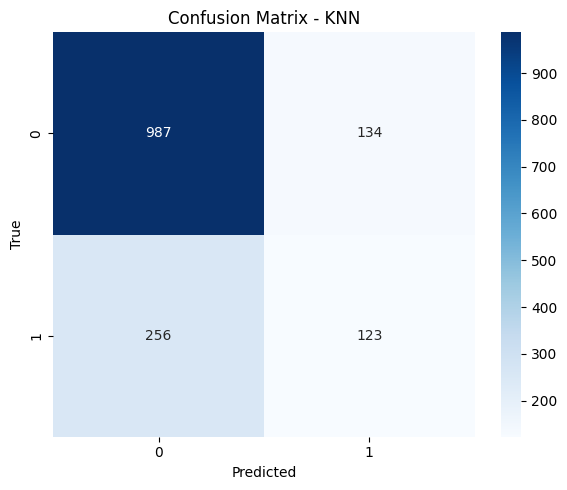

In [ ]:
metrics = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}

for name, mdl in models.items():
    if name == 'Neural Network':
        y_pred = np.argmax(mdl.predict(X_test), axis=1)
    else:
        y_pred = mdl.predict(X_test)

    metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['Precision'].append(precision_score(y_test, y_pred, average='weighted'))
    metrics['Recall'].append(recall_score(y_test, y_pred, average='weighted'))
    metrics['F1 Score'].append(f1_score(y_test, y_pred, average='weighted'))

# Plot bar charts
plt.figure(figsize=(10, 6))
for i, (metric, values) in enumerate(metrics.items()):
    plt.bar([x + i*0.13 for x in range(len(models))], values, width=0.13, label=metric)

plt.xticks([r + 0.26 for r in range(len(models))], models.keys(), rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison: Accuracy, Precision, Recall, F1')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Confusion Matrices
for name, mdl in models.items():
    if name == 'Neural Network':
        y_pred = np.argmax(mdl.predict(X_test), axis=1)
    else:
        y_pred = mdl.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

**Verdict**

![alt text](https://i.imgur.com/gCPvJpO.png)